# SAAM Project 2026

## 0. Setup

Imports, paths, parameters, and helper functions.

In [ ]:
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

# =============================================================================
# Paths
# =============================================================================

BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / "csv_raw_data"
CLEAN_DIR = BASE_DIR / "cleaned_data"
OUT_DIR = BASE_DIR / "results"

# Create output folders if they do not already exist
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# Project settings
# =============================================================================

REGIONS = ["AMER", "EUR"]

START_YEAR = 2013
END_YEAR = 2024
WINDOW_YEARS = 10
MIN_VALID_MONTHS = 36
STALE_THRESHOLD = 0.50

# Raw files
STATIC_FILE = "Static_2025.csv"
RI_FILE = "DS_RI_T_USD_M_2025.csv"
MV_FILE = "DS_MV_T_USD_M_2025.csv"
CO2_FILE = "DS_CO2_SCOPE_1_Y_2025.csv"
REV_FILE = "DS_REV_Y_2025.csv"

# Cleaned/output files
RI_PRICES_FILE = "cleaned_RI_monthly_prices.csv"
RI_RETURNS_FILE = "cleaned_RI_monthly_returns.csv"
MV_CLEAN_FILE = "cleaned_MV_monthly.csv"
CO2_CLEAN_FILE = "cleaned_CO2_scope1_yearly.csv"
REV_CLEAN_FILE = "cleaned_REV_yearly.csv"
INV_SET_FILE = "investment_set_by_year.csv"
MVP_W_FILE = "mvp_weights_by_year.csv"
MVP_RET_FILE = "mvp_monthly_returns.csv"
VW_RET_FILE = "vw_monthly_returns.csv"


# =============================================================================
# Helper functions
# =============================================================================

def clean_headers(df):
    # Remove extra spaces from column names
    df.columns = [str(c).strip() for c in df.columns]
    return df


def get_id_cols(df):
    # Find the NAME and ISIN columns
    upper = {c.upper(): c for c in df.columns}
    return upper.get("NAME"), upper.get("ISIN")


def get_time_cols(df):
    # Return all columns except NAME and ISIN
    name_col, isin_col = get_id_cols(df)
    exclude = {c for c in [name_col, isin_col] if c is not None}
    return [c for c in df.columns if c not in exclude]


def sort_month_cols(cols):
    # Sort monthly columns in time order
    try:
        dt = pd.to_datetime(cols, errors="coerce")
        if dt.notna().all():
            return [c for _, c in sorted(zip(dt, cols))]
        return sorted(cols)
    except Exception:
        return sorted(cols)


def sort_year_cols(cols):
    # Sort yearly columns in time order
    def parse_year(x):
        try:
            return int(str(x)[:4])
        except Exception:
            return 999999
    return sorted(cols, key=parse_year)


def get_december_col(month_cols, year):
    # Return the December column for a given year
    dts = pd.to_datetime(month_cols, errors="coerce")
    candidates = [c for c, d in zip(month_cols, dts)
                  if pd.notna(d) and d.year == year and d.month == 12]
    return candidates[-1] if candidates else None


def get_trailing_window_cols(month_cols, end_year, window_years=10):
    # Return the monthly columns in the rolling estimation window
    # Example: if end_year = 2013, this gives Jan 2004 to Dec 2013
    end_dt = pd.Timestamp(f"{end_year}-12-31")
    start_dt = end_dt - pd.DateOffset(years=window_years)
    col_dates = pd.to_datetime(month_cols, errors="coerce")

    return [c for c, d in zip(month_cols, col_dates)
            if pd.notna(d) and start_dt < d <= end_dt]


def get_investment_year_cols(month_cols, investment_year):
    # Return the monthly columns in the investment year
    col_dates = pd.to_datetime(month_cols, errors="coerce")
    return [c for c, d in zip(month_cols, col_dates)
            if pd.notna(d) and d.year == investment_year]


def drop_empty_timeseries_rows(df):
    # Remove firms where all time-series values are missing
    df = clean_headers(df)
    _, isin_col = get_id_cols(df)
    time_cols = get_time_cols(df)

    df = df.dropna(subset=[isin_col]).copy()
    df[time_cols] = df[time_cols].apply(pd.to_numeric, errors="coerce")

    return df.loc[~df[time_cols].isna().all(axis=1)].copy()


def keep_isins(df, valid_isins):
    # Keep only firms in the chosen ISIN set
    _, isin_col = get_id_cols(df)
    return df[df[isin_col].isin(valid_isins)].copy()


def annual_forward_fill(df):
    # Forward-fill annual data (middle/end gaps only; beginning gaps stay NaN).
    out = df.copy()
    year_cols = sort_year_cols(get_time_cols(out))
    out[year_cols] = out[year_cols].apply(pd.to_numeric, errors="coerce")
    out[year_cols] = out[year_cols].ffill(axis=1)
    return out


def detect_delisting(df):
    # Set price to 0 at/after delisting date so that compute_monthly_returns
    # records a -100 % return for the final month.

    out = df.copy()
    name_col, _ = get_id_cols(out)

    if name_col is None:
        return out

    month_cols = sort_month_cols(get_time_cols(out))
    month_dates = pd.to_datetime(month_cols, errors="coerce")

    # Look for a date in the format DD/MM/YYYY inside the name
    date_pattern = re.compile(r"\d{2}/\d{2}/\d{4}")

    for idx in out.index:
        name = str(out.at[idx, name_col]).upper()

        # Case 1: name contains both a date and the word "DELIST"
        if "DELIST" in name:
            match = date_pattern.search(name)

            if match:
                try:
                    delist_date = pd.to_datetime(match.group(), dayfirst=True)
                except:
                    continue

                for col, dt in zip(month_cols, month_dates):
                    if pd.notna(dt) and dt >= delist_date:
                        out.at[idx, col] = 0.0

        # Case 2: name contains "DEAD" but no date
        elif "DEAD" in name:
            values = out.loc[idx, month_cols]
            last_valid = values.last_valid_index()

            if last_valid is not None and last_valid != month_cols[-1]:
                next_pos = month_cols.index(last_valid) + 1
                out.at[idx, month_cols[next_pos]] = 0.0

    return out

def compute_monthly_returns(ri_prices):
    # Simple monthly return R_t = P_t/P_{t-1} - 1; delisted firms get -1.0; gaps stay NaN.

    df = ri_prices.copy()
    name_col, isin_col = get_id_cols(df)
    month_cols = sort_month_cols(get_time_cols(df))
    id_cols_list = [c for c in [name_col, isin_col] if c is not None]

    returns = df[id_cols_list].copy()

    for i, col in enumerate(month_cols):
        if i == 0:
            returns[col] = np.nan
            continue

        prev_col = month_cols[i - 1]
        prev = df[prev_col].values.astype(float)
        curr = df[col].values.astype(float)
        ret = np.full(len(df), np.nan)

        valid = (~np.isnan(prev)) & (prev > 0) & (~np.isnan(curr)) & (curr > 0)
        ret[valid] = curr[valid] / prev[valid] - 1.0

        delist = (curr == 0.0) & (~np.isnan(prev)) & (prev > 0)
        ret[delist] = -1.0

        returns[col] = ret

    return returns


def flag_stale_prices(returns_df, end_year, window_years=10, threshold=0.50):
    # Return a DataFrame with stale-price diagnostics per firm over the
    # trailing window_years-year window ending December of end_year.

    _, isin_col = get_id_cols(returns_df)
    month_cols = sort_month_cols(get_time_cols(returns_df))
    window_cols = get_trailing_window_cols(
        month_cols, end_year=end_year, window_years=window_years
    )

    # If no valid trailing window is found, return an empty diagnostics table
    if not window_cols:
        return pd.DataFrame(columns=["ISIN", "n_valid", "n_zero", "zero_frac", "stale_flag"])

    # Keep only the returns in the estimation window
    data = returns_df[window_cols].apply(pd.to_numeric, errors="coerce")

    # Count available observations and zero returns for each firm
    n_valid = data.notna().sum(axis=1)
    n_zero = (data == 0.0).sum(axis=1)
    zero_frac = n_zero / n_valid.replace(0, np.nan)

    out = pd.DataFrame({
        "ISIN": returns_df[isin_col].values,
        "n_valid": n_valid.values,
        "n_zero": n_zero.values,
        "zero_frac": zero_frac.values,
    })

    # Flag firms with too many zero returns as stale-price firms
    out["stale_flag"] = out["zero_frac"] > threshold

    return out


def ledoit_wolf_cov(R_dem, S):
    # Ledoit-Wolf (2004) shrinkage of the sample covariance toward a scaled
    # identity target F = (trace(S)/n) * I.
    #
    # With n >> tau (here n ~ 770-1100, tau = 120), the sample covariance S is
    # rank-deficient (rank <= tau), so the TE-min QP has a huge null space and
    # the solver can move w arbitrarily far from w_vw at zero TE cost. This
    # produces degenerate corner solutions (e.g. P(vw)_oos(0.5) and
    # P(vw)_oos(NZ) both collapsing to the same vertex with TE ~ 0 and CF
    # well below either constraint cap). Shrinkage gives a full-rank PD
    # estimate so the active-weight quadratic form has no flat directions.
    #
    # R_dem : (tau, n) de-meaned returns
    # S     : (n, n) sample covariance (1/tau)
    tau, n = R_dem.shape

    trace_avg = np.trace(S) / n
    F         = trace_avg * np.eye(n)

    R_dem_sq  = R_dem ** 2
    pi_hat    = ((R_dem_sq.T @ R_dem_sq) / tau - S ** 2).sum()
    gamma_hat = ((S - F) ** 2).sum()
    if gamma_hat <= 0:
        delta = 0.0
    else:
        delta = max(0.0, min(1.0, (pi_hat / gamma_hat) / tau))

    return delta * F + (1.0 - delta) * S, delta


def estimate_moments(ri_ret_by_isin, isins, window_cols):
    ret_mat = (
        ri_ret_by_isin.reindex(isins)[window_cols]
        .apply(pd.to_numeric, errors="coerce")
    )

    # Keep only firms with a complete return history over the full window
    complete_mask = ret_mat.notna().all(axis=1)
    ret_mat = ret_mat[complete_mask]
    valid_isins = list(ret_mat.index)

    if not valid_isins:
        return None, None, []

    R = ret_mat.values.T   # shape (tau, N)
    tau = float(R.shape[0])

    mu = R.mean(axis=0)

    # Sample covariance: biased MLE (1/tau), consistent with project specification
    R_dem = R - mu[np.newaxis, :]
    S     = (R_dem.T @ R_dem) / tau

    # Regularize via Ledoit-Wolf shrinkage (full-rank PD estimate).
    cov, _delta = ledoit_wolf_cov(R_dem, S)

    cov = 0.5 * (cov + cov.T)   # symmetry safety

    return mu, cov, valid_isins


def solve_mvp(cov):
    # Solve long-only minimum variance portfolio

    n = cov.shape[0]
    w = cp.Variable(n)

    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov))),
        [cp.sum(w) == 1, w >= 0]
    )

    prob.solve(solver=cp.OSQP, verbose=False)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"MVP optimisation failed: {prob.status}")

    weights = np.clip(np.array(w.value).flatten(), 0, None)

    return weights / weights.sum()


def summary_stats(series, name, rf_monthly):
    # Compute annualised performance statistics from a monthly return series.
    ann = 12
    vals = series.to_numpy(dtype=float)
    mu = vals.mean()
    std = vals.std(ddof=1)
    excess_return = mu - rf_monthly


    return {
        "portfolio": name,
        "start_date": series.index.min().strftime("%Y-%m"),
        "end_date": series.index.max().strftime("%Y-%m"),
        "n_months": len(vals),
        "ann_mean_return": mu * ann,
        "ann_volatility": std * np.sqrt(ann),
        "sharpe_ratio": np.nan if std == 0 else (excess_return / std) * np.sqrt(ann),        
        "min_monthly_return": vals.min(),
        "max_monthly_return": vals.max(),
    }



# Part I - Standard Portfolio Allocation
## 1. Data Cleaning

Raw Datastream files are loaded and cleaned in five steps:
1. Filter to the assigned region universe (North America + Europe)
2. Detect and handle delisted firms (price set to 0, return = -100%)
3. Treat RI prices below 0.5 as missing to avoid infinite returns
4. Forward-fill missing annual CO2 and revenue data (middle/end gaps only)
5. Intersect a common ISIN universe across all files

Note: stale-price screening is **not** applied here — it is applied year-by-year in Section 2.1 to avoid look-ahead bias.

In [ ]:

# 1. LOAD RAW FILES
static = clean_headers(pd.read_csv(RAW_DIR / STATIC_FILE))
ri     = clean_headers(pd.read_csv(RAW_DIR / RI_FILE))
mv     = clean_headers(pd.read_csv(RAW_DIR / MV_FILE))
co2    = clean_headers(pd.read_csv(RAW_DIR / CO2_FILE))
rev    = clean_headers(pd.read_csv(RAW_DIR / REV_FILE))

# 2. FILTER STATIC TO ASSIGNED REGIONS
static_name_col, static_isin_col = get_id_cols(static)
if static_isin_col is None:
    raise ValueError("Static file must contain an ISIN column.")
if "Region" not in static.columns:
    raise ValueError("Static file must contain a 'Region' column.")

static = static.dropna(subset=[static_isin_col]).copy()
static = static[static["Region"].isin(REGIONS)].copy()

# 3. DROP ROWS WITH NO TIME-SERIES DATA AT ALL
ri  = drop_empty_timeseries_rows(ri)
mv  = drop_empty_timeseries_rows(mv)
co2 = drop_empty_timeseries_rows(co2)
rev = drop_empty_timeseries_rows(rev)

# 4. RESTRICT TO REGION UNIVERSE
region_isins = set(static[static_isin_col])
ri  = keep_isins(ri,  region_isins)
mv  = keep_isins(mv,  region_isins)
co2 = keep_isins(co2, region_isins)
rev = keep_isins(rev, region_isins)

# 5. CLEAN RI: delisting -> low prices -> compute returns
ri_month_cols = sort_month_cols(get_time_cols(ri))
ri[ri_month_cols] = ri[ri_month_cols].apply(pd.to_numeric, errors="coerce")

# Delisting must be flagged BEFORE the low-price filter (delist sets price to exact 0)
ri = detect_delisting(ri)

# Treat prices in (0, 0.5) as missing; preserve exact 0.0 for delisted firms
for c in ri_month_cols:
    mask = (ri[c] < 0.5) & (ri[c] > 0)
    ri.loc[mask, c] = np.nan

ri     = ri.loc[~ri[ri_month_cols].isna().all(axis=1)].copy()
ri_ret = compute_monthly_returns(ri)

# 6. CLEAN MV (numeric conversion only; no fill needed for monthly data)
mv_month_cols = sort_month_cols(get_time_cols(mv))
mv[mv_month_cols] = mv[mv_month_cols].apply(pd.to_numeric, errors="coerce")

# 7. FORWARD-FILL ANNUAL DATA (middle/end gaps only; beginning gaps stay NaN)
co2 = annual_forward_fill(co2)
rev = annual_forward_fill(rev)

# 8. INTERSECT COMMON ISIN UNIVERSE ACROSS ALL FILES
_, ri_isin_col  = get_id_cols(ri)
_, mv_isin_col  = get_id_cols(mv)
_, co2_isin_col = get_id_cols(co2)
_, rev_isin_col = get_id_cols(rev)

common_isins = (
    set(static[static_isin_col])
    & set(ri[ri_isin_col])
    & set(mv[mv_isin_col])
    & set(co2[co2_isin_col])
    & set(rev[rev_isin_col])
)
static = keep_isins(static, common_isins).sort_values(static_isin_col).reset_index(drop=True)
ri     = keep_isins(ri,     common_isins).sort_values(ri_isin_col).reset_index(drop=True)
ri_ret = keep_isins(ri_ret, common_isins).sort_values(ri_isin_col).reset_index(drop=True)
mv     = keep_isins(mv,     common_isins).sort_values(mv_isin_col).reset_index(drop=True)
co2    = keep_isins(co2,    common_isins).sort_values(co2_isin_col).reset_index(drop=True)
rev    = keep_isins(rev,    common_isins).sort_values(rev_isin_col).reset_index(drop=True)

# 9. SAVE
static.to_csv(CLEAN_DIR / "cleaned_static.csv", index=False)
ri.to_csv(    CLEAN_DIR / RI_PRICES_FILE,        index=False)
ri_ret.to_csv(CLEAN_DIR / RI_RETURNS_FILE,       index=False)
mv.to_csv(    CLEAN_DIR / MV_CLEAN_FILE,         index=False)
co2.to_csv(   CLEAN_DIR / CO2_CLEAN_FILE,        index=False)
rev.to_csv(   CLEAN_DIR / REV_CLEAN_FILE,        index=False)

print(f"  Common universe: {len(common_isins)} firms")
print(f"  Saved to: {CLEAN_DIR}")

C:\Users\zagor\AppData\Local\Temp\ipykernel_22244\2364079514.py:221: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns[col] = ret


  Common universe: 1209 firms
  Saved to: c:\Users\zagor\Vlad\M\Sustainability\Project\cleaned_data


## 2.1 Investment Set

For each screen year $Y \in \{2013, \ldots, 2024\}$, a firm is investable in $Y+1$ if:

1. **Region** — assigned universe (AMER / EUR)
2. **Return history** — at least 36 non-missing monthly returns in the trailing 10-year window
3. **Carbon data** — Scope 1 CO\u2082 and revenues available at end of $Y$
4. **Stale prices** — fewer than 50\,% zero returns in the trailing window

Expected returns and covariance are estimated from the 10-year trailing window ($\omega = 120$):

$$\hat{\mu}_Y = \frac{1}{\omega}\sum_{k=0}^{\omega-1} R_{t-k}, \qquad \hat{\Sigma}_Y = \frac{1}{\omega}\sum_{k=0}^{\omega-1}(R_{t-k}-\hat{\mu}_Y)(R_{t-k}-\hat{\mu}_Y)^\top$$

In [ ]:
# =============================================================================
# 1. Region filter
# =============================================================================

# Load the static file (ISIN, Name, Country, Region)
static = clean_headers(pd.read_csv(RAW_DIR / STATIC_FILE))

# Keep only firms belonging to the assigned regions
region_col = [c for c in static.columns if c.upper() == "REGION"][0]
isin_col   = [c for c in static.columns if c.upper() == "ISIN"][0]

region_mask    = static[region_col].isin(REGIONS)
eligible_isins = static.loc[region_mask, isin_col].unique().tolist()

print(f"Total firms in static file : {len(static)}")
print(f"Firms after region filter  : {len(eligible_isins)}")
print(f"Regions kept               : {REGIONS}")

# =============================================================================
# 2. Sufficient return history
# =============================================================================

# Load the cleaned monthly returns
ri_returns = clean_headers(pd.read_csv(CLEAN_DIR / RI_RETURNS_FILE))

# Find the ISIN column and isolate the date columns
isin_col      = [c for c in ri_returns.columns if c.upper() == "ISIN"][0]
all_date_cols = [c for c in ri_returns.columns if c != isin_col]

# Work only on the firms that passed Criterion 1
ri_returns = ri_returns[ri_returns[isin_col].isin(eligible_isins)]
ri_returns = ri_returns.set_index(isin_col)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    date_index = pd.to_datetime(all_date_cols, errors="coerce")

criterion2_results = []

for year in range(START_YEAR, END_YEAR + 1):

    window_end   = pd.Timestamp(f"{year}-12-31")
    window_start = window_end - pd.DateOffset(years=WINDOW_YEARS)

    # Pick the date columns that fall strictly inside the window
    # (window_start, window_end] means we exclude the start boundary but include the end
    window_cols = [
        c for c, d in zip(all_date_cols, date_index)
        if pd.notna(d) and window_start < d <= window_end
    ]

    window_returns = ri_returns[window_cols].apply(pd.to_numeric, errors="coerce")

    valid_months = window_returns.notna().sum(axis=1)

    passes = valid_months >= MIN_VALID_MONTHS

    for isin in ri_returns.index:
        criterion2_results.append({
            "screen_year":       year,
            "ISIN":              isin,
            "valid_months":      int(valid_months[isin]),
            "passes_criterion2": bool(passes[isin]),
        })

criterion2_df = pd.DataFrame(criterion2_results)

# =============================================================================
# 3. Carbon data availability
# =============================================================================

# Load cleaned CO2 and revenue data 
co2_clean = clean_headers(pd.read_csv(CLEAN_DIR / CO2_CLEAN_FILE))
rev_clean = clean_headers(pd.read_csv(CLEAN_DIR / REV_CLEAN_FILE))

co2_clean.columns = [str(c) for c in co2_clean.columns]
rev_clean.columns = [str(c) for c in rev_clean.columns]

isin_col_co2 = [c for c in co2_clean.columns if c.upper() == "ISIN"][0]
isin_col_rev = [c for c in rev_clean.columns if c.upper() == "ISIN"][0]

co2_clean = co2_clean.set_index(isin_col_co2)
rev_clean = rev_clean.set_index(isin_col_rev)

criterion3_results = []

for year in range(START_YEAR, END_YEAR + 1):
    year_str = str(year)

    co2_available = co2_clean[year_str].notna() if year_str in co2_clean.columns else pd.Series(False, index=co2_clean.index)
    rev_available = rev_clean[year_str].notna() if year_str in rev_clean.columns else pd.Series(False, index=rev_clean.index)

    passes = co2_available & rev_available

    for isin in co2_clean.index:
        criterion3_results.append({
            "screen_year":       year,
            "ISIN":              isin,
            "passes_criterion3": bool(passes.get(isin, False)),
        })

criterion3_df = pd.DataFrame(criterion3_results)

# =============================================================================
# 4. Stale-price filter
# =============================================================================

# Load full returns file (not the filtered one) so flag_stale_prices can work
ri_ret_full = clean_headers(pd.read_csv(CLEAN_DIR / RI_RETURNS_FILE))

criterion4_results = []

for year in range(START_YEAR, END_YEAR + 1):
    stale_df = flag_stale_prices(ri_ret_full, end_year=year,
                                  window_years=WINDOW_YEARS,
                                  threshold=STALE_THRESHOLD)
    stale_isins = set(stale_df.loc[stale_df["stale_flag"], "ISIN"])

    for isin in eligible_isins:
        is_stale = isin in stale_isins
        criterion4_results.append({
            "screen_year":       year,
            "ISIN":              isin,
            "passes_criterion4": not is_stale,
        })

criterion4_df = pd.DataFrame(criterion4_results)

# =============================================================================
# 5. Combine criteria and estimate mu / Sigma
# =============================================================================

# Merge all four criteria into one master table
inv_set = (criterion2_df
           .merge(criterion3_df, on=["screen_year", "ISIN"])
           .merge(criterion4_df, on=["screen_year", "ISIN"])
           .merge(pd.DataFrame({"ISIN": eligible_isins}), on="ISIN"))

# investable = region (C1) AND history (C2) AND carbon (C3) AND not stale (C4)
inv_set["investable"] = (
    inv_set["passes_criterion2"] &
    inv_set["passes_criterion3"] &
    inv_set["passes_criterion4"]
)

moments_by_year = {}  # stores {"year": {"mu": ..., "cov": ..., "isins": ...}}

for year in range(START_YEAR, END_YEAR + 1):

    # ISINs that passed all criteria for this screen year
    mask   = (inv_set["screen_year"] == year) & inv_set["investable"]
    isins  = inv_set.loc[mask, "ISIN"].tolist()

    # Same trailing window as Criterion 2
    window_end   = pd.Timestamp(f"{year}-12-31")
    window_start = window_end - pd.DateOffset(years=WINDOW_YEARS)
    window_cols  = [
        c for c, d in zip(all_date_cols, date_index)
        if pd.notna(d) and window_start < d <= window_end
    ]

    # Use the corrected helper function to compute pairwise covariance
    mu, cov, valid_isins = estimate_moments(ri_returns, isins, window_cols)
    
    if len(valid_isins) == 0:
        print(f"{year}: no complete firms, skipping.")
        continue
    
    moments_by_year[year] = {"mu": mu, "cov": cov, "isins": valid_isins}
    
# =============================================================================
# 6. Output the investment set table
# =============================================================================

# Only keep firms that survived dropna() in step 2
for year, data in moments_by_year.items():
    complete_isins = data["isins"]
    inv_set.loc[
        (inv_set["screen_year"] == year) & ~inv_set["ISIN"].isin(complete_isins),
        "investable"
    ] = False

# Rename columns to match what downstream cells expect
investment_set = inv_set[["screen_year", "ISIN", "investable"]].copy()
investment_set["investment_year"] = investment_set["screen_year"] + 1
investment_set.rename(columns={"investable": "investable_for_next_year"}, inplace=True)
investment_set.to_csv(CLEAN_DIR / INV_SET_FILE, index=False)

# Sanity check of the data

from IPython.display import display

# Group by year and count the 'True' values for every criterion at once
master_summary = inv_set.groupby("screen_year")[
    ["passes_criterion2", "passes_criterion3", "passes_criterion4", "investable"]
].sum()

master_summary = master_summary.rename(columns={
    "passes_criterion2": "Passed 3-Yr History",
    "passes_criterion3": "Passed Carbon Data",
    "passes_criterion4": "Passed Stale Price",
    "investable":        "FINAL INVESTABLE"
})

display(master_summary.T)


Total firms in static file : 2545
Firms after region filter  : 1302
Regions kept               : ['AMER', 'EUR']


screen_year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Passed 3-Yr History,1185,1187,1187,1191,1191,1194,1195,1196,1197,1198,1198,1202
Passed Carbon Data,837,863,896,918,952,1010,1100,1143,1175,1199,1206,1209
Passed Stale Price,1209,1209,1209,1209,1209,1209,1209,1209,1209,1209,1209,1209
FINAL INVESTABLE,771,811,862,895,931,984,1073,1115,1148,1147,1136,1120


## 2.2 MVP

For each screen year $Y$, we solve:

$$\min_{\alpha_Y}\; \alpha_Y^\top \hat{\Sigma}_Y \alpha_Y \quad\text{s.t.}\quad \alpha_Y^\top e = 1,\; \alpha_{i,Y} \geq 0$$

Firms with any missing return in the trailing window are excluded.

In [ ]:

ri_returns      = clean_headers(pd.read_csv(CLEAN_DIR / RI_RETURNS_FILE))
_, ret_isin_col  = get_id_cols(ri_returns)
ret_month_cols   = sort_month_cols(get_time_cols(ri_returns))
ri_ret_by_isin   = ri_returns.set_index(ret_isin_col)
weights_rows      = []
year_summary_rows = []
mvp_return_rows   = []


for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    investable_isins = investment_set.loc[ 
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"], "ISIN"
        ].tolist()

    if not investable_isins:
        print(f"{year} is skipped. There are no investable firms.")
        continue
    
    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year, window_years=WINDOW_YEARS)

    if not window_cols:
        print(f"{year} is skipped. There are no trailing window columns.")
        continue
    
    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)

    if not valid_isins:
        print(f"{year} is skipped. There are no complete-case assets available.")
        continue
    
    weights = solve_mvp(cov)

    port_variance = weights.T @ cov @ weights


    for isin, w in zip(valid_isins, weights):
        weights_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "ISIN":            isin,
            "weight":          w,
        })

    year_summary_rows.append({
        "screen_year":       year,
        "investment_year":   investment_year,
        "n_investable":      len(investable_isins),
        "n_assets_in_cov":   len(valid_isins),
        "n_dropped_missing": len(investable_isins) - len(valid_isins),
        "max_weight":        float(weights.max()),
    })

    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue

    current_weights = pd.Series(weights, index=valid_isins)

    for col in inv_cols:
        month_rets = ri_ret_by_isin.reindex(valid_isins)[col].apply(pd.to_numeric, errors="coerce")
        valid_mask = month_rets.notna()
        w_m = current_weights[valid_mask]
        r_m = month_rets[valid_mask]
        rp  = float((w_m / w_m.sum() * r_m).sum()) if w_m.sum() > 1e-8 else 0.0

        mvp_return_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "date":            pd.Timestamp(col),
            "Rp_mvp":          rp,
        })

        new_w = current_weights.copy()
        new_w[valid_mask] = current_weights[valid_mask] * (1.0 + month_rets[valid_mask])
        if new_w.sum() > 1e-8:
            current_weights = new_w / new_w.sum()
            
weights_by_year = pd.DataFrame(weights_rows)
weights_by_year.to_csv(OUT_DIR / MVP_W_FILE, index=False)
pd.DataFrame(year_summary_rows).to_csv(OUT_DIR / "mvp_weights_summary_by_year.csv", index=False)

mvp_monthly_returns = pd.DataFrame(mvp_return_rows).sort_values("date").reset_index(drop=True)
mvp_monthly_returns.to_csv(OUT_DIR / MVP_RET_FILE, index=False)

## 2.3 Comparison with Value-Weighted Benchmark

The VW benchmark rebalances monthly using end-of-prior-month market caps:

$$R^{(vw)}_{t} = \sum_{i} w_{i,t-1}\, R_{i,t}, \qquad w_{i,t-1} = \frac{\mathrm{Cap}_{i,t-1}}{\sum_j \mathrm{Cap}_{j,t-1}}$$

MVP weights are set at end of year $Y$ and drift through $Y+1$:

$$\alpha_{i,t} = \alpha_{i,t-1}\,\frac{1+R_{i,t}}{1+R_{p,t}}$$

We report annualised mean return, volatility, Sharpe ratio, and min/max monthly return for both portfolios over Jan 2014\u2013Dec 2025.

Average monthly RF rate: 0.1456%
Implied annual RF rate:  1.7475%


,Portfolio,Ann. Return,Ann. Volatility,Sharpe Ratio,Min Monthly Ret.,Max Monthly Ret.
0,P(mv)_oos,7.36%,11.58%,0.485,-11.77%,10.74%
1,P(vw)_oos,11.61%,14.17%,0.696,-13.07%,12.84%


,Screen Year,N Firms
0,2013,771
1,2014,811
2,2015,862
3,2016,895
4,2017,931
5,2018,984
6,2019,1073
7,2020,1115
8,2021,1148
9,2022,1147


,ISIN,NAME,weight
1,US9311421039,WALMART,8.42%
2,US4278661081,HERSHEY,6.64%
3,CH0014786500,VALIANT 'R',6.57%
4,US3703341046,GENERAL MILLS,5.90%
5,US2091151041,CONSOLIDATED EDISON,5.50%
6,US74834L1008,QUEST DIAGNOSTICS,5.41%
7,US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,5.06%
8,US8425871071,SOUTHERN,4.47%
9,DK0060448595,COLOPLAST B,3.79%
10,US8725401090,TJX,3.64%


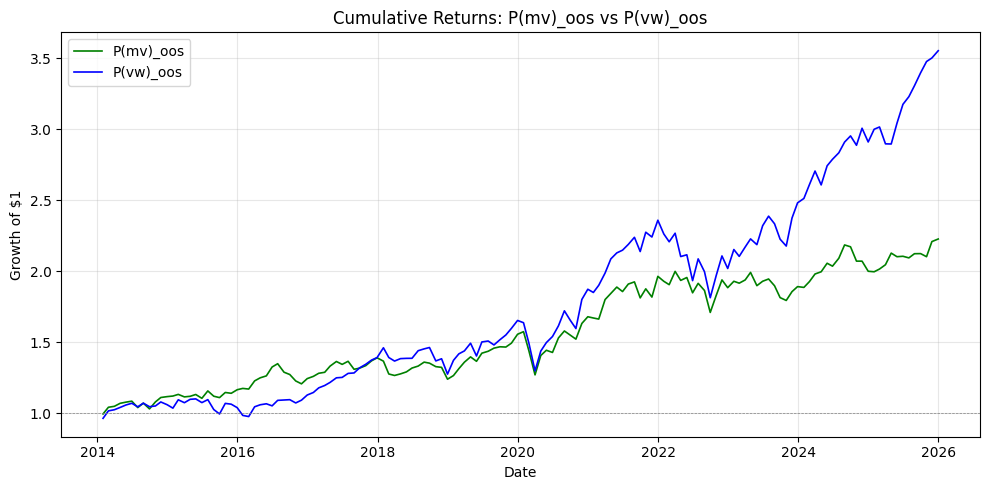

In [ ]:
# =============================================================================
# 1. Load monthly market cap data
# =============================================================================

mv_clean = clean_headers(pd.read_csv(CLEAN_DIR / MV_CLEAN_FILE))
_, mv_isin_col = get_id_cols(mv_clean)
mv_month_cols = sort_month_cols(get_time_cols(mv_clean))
mv_by_isin = mv_clean.set_index(mv_isin_col)

# =========================================================================
# 2. Build monthly value-weighted benchmark returns
# =========================================================================

vw_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year)
        & (investment_set["investable_for_next_year"] == True),
        "ISIN"
    ].tolist()

    if not investable_isins:
        continue

    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue

    for col in inv_cols:
        current_dt = pd.Timestamp(col)
        prev_month_dt = current_dt - pd.DateOffset(months=1)

        # Match by year-month period to avoid end-of-month date mismatch
        target_period   = prev_month_dt.to_period("M")
        prev_candidates = [c for c in mv_month_cols if pd.Timestamp(c).to_period("M") == target_period]
        if not prev_candidates:
            continue

        prev_col = prev_candidates[0]

        caps = mv_by_isin.reindex(investable_isins)[prev_col].apply(pd.to_numeric, errors="coerce")
        rets = ri_ret_by_isin.reindex(investable_isins)[col].apply(pd.to_numeric, errors="coerce")


        valid = caps.notna() & rets.notna() & (caps > 0)
        caps = caps[valid]
        rets = rets[valid]

        if caps.empty:
            continue

        weights_vw = caps / caps.sum()
        rp_vw = float((weights_vw * rets).sum())

        vw_rows.append({
            "screen_year": year,
            "investment_year": investment_year,
            "date": current_dt,
            "Rp_vw": rp_vw
        })

vw_monthly_returns = pd.DataFrame(vw_rows).sort_values("date").reset_index(drop=True)

if vw_monthly_returns.empty:
    raise RuntimeError("No value-weighted returns were generated.")

# =============================================================================
# 3. Merge MVP and benchmark returns & load risk-free rate for performance comparison
# =============================================================================

compare_df = (
    mvp_monthly_returns[["date", "Rp_mvp"]]
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .merge(
        vw_monthly_returns[["date", "Rp_vw"]]
        .assign(date=lambda x: pd.to_datetime(x["date"])),
        on="date",
        how="inner"
    )
    .sort_values("date")
    .set_index("date")
)

if compare_df.empty:
    raise RuntimeError("Merged comparison dataframe is empty.")

compare_df["cum_mvp"] = (1.0 + compare_df["Rp_mvp"]).cumprod()
compare_df["cum_vw"]  = (1.0 + compare_df["Rp_vw"]).cumprod()


# Load the risk-free rate data
rf_raw = pd.read_csv(RAW_DIR / "Risk_Free_Rate_2025.csv")

# Normalise column names
rf_raw.columns = [str(c).strip() for c in rf_raw.columns]

# Identify date and rate columns (adjust names below if your file uses different headers)
date_col_rf = rf_raw.columns[0]   # first column dates in YYYYMM format
rate_col_rf = rf_raw.columns[1]   # second column rates

# Convert YYYYMM format to datetime (e.g., 200001 -> 2000-01-01)
rf_raw[date_col_rf] = pd.to_datetime(rf_raw[date_col_rf], format='%Y%m')
rf_raw[rate_col_rf] = pd.to_numeric(rf_raw[rate_col_rf], errors="coerce")

rf_raw["rf_monthly"] = rf_raw[rate_col_rf] / 100 

# Filter to the same period as the portfolio returns
sample_start = pd.to_datetime("2014-01-01")
sample_end   = compare_df.index.max()

rf_in_sample = rf_raw[
    (rf_raw[date_col_rf] >= sample_start) &
    (rf_raw[date_col_rf] <= sample_end)
]

rf_monthly_avg = rf_in_sample["rf_monthly"].mean()

print(f"Average monthly RF rate: {rf_monthly_avg:.4%}")
print(f"Implied annual RF rate:  {rf_monthly_avg * 12:.4%}")

# =============================================================================
# 4. Compare performance statistics
# =============================================================================

mvp_stats = summary_stats(compare_df["Rp_mvp"], "P(mv)_oos", rf_monthly=rf_monthly_avg)
vw_stats  = summary_stats(compare_df["Rp_vw"],  "P(vw)_oos", rf_monthly=rf_monthly_avg)

comparison_summary = pd.DataFrame([mvp_stats, vw_stats])

# =============================================================================
# 5. Table 1: Performance summary
# =============================================================================

display_df = comparison_summary[
    ["portfolio", "ann_mean_return", "ann_volatility",
     "sharpe_ratio", "min_monthly_return", "max_monthly_return"]
].copy()

display_df.columns = [
    "Portfolio", "Ann. Return", "Ann. Volatility",
    "Sharpe Ratio", "Min Monthly Ret.", "Max Monthly Ret."
]

for col in ["Ann. Return", "Ann. Volatility", "Min Monthly Ret.", "Max Monthly Ret."]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}")

display_df["Sharpe Ratio"] = display_df["Sharpe Ratio"].apply(lambda x: f"{x:.3f}")

display(display_df)

# =============================================================================
# 6. Table 2: Number of investable firms by year
# =============================================================================

inv_by_year = (
    investment_set[investment_set["investable_for_next_year"]]
    .groupby("screen_year")["ISIN"]
    .count()
    .rename("N Firms")
    .reset_index()
    .rename(columns={"screen_year": "Screen Year"})
)

display(inv_by_year)

# =============================================================================
# 7. Table 3: Largest MVP holdings in first portfolio
# =============================================================================

static = clean_headers(pd.read_csv(RAW_DIR / STATIC_FILE))
isin_col = [c for c in static.columns if c.upper() == 'ISIN'][0]
name_col = [c for c in static.columns if c.upper() == 'NAME'][0]
isin_to_name = dict(zip(static[isin_col], static[name_col]))

first_screen_year = weights_by_year["screen_year"].min()

top10 = (
    weights_by_year[weights_by_year["screen_year"] == first_screen_year]
    .nlargest(10, "weight")[["ISIN", "weight"]]
    .copy()
    .reset_index(drop=True)
)

top10.insert(1, "NAME", top10["ISIN"].map(isin_to_name))

top10.index = range(1, 11)
top10["weight"] = top10["weight"].apply(lambda x: f"{x:.2%}")

display(top10[["ISIN", "NAME", "weight"]])

# =============================================================================
# 8. Cumulative return plot
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(compare_df.index, compare_df["cum_mvp"], label="P(mv)_oos", linewidth=1.2, color="green")
ax.plot(compare_df.index, compare_df["cum_vw"],  label="P(vw)_oos", linewidth=1.2, color="blue")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.5)
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.set_title("Cumulative Returns: P(mv)_oos vs P(vw)_oos")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "cumulative_returns_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 9. Save outputs
# =============================================================================

vw_monthly_returns.to_csv(OUT_DIR / VW_RET_FILE, index=False)
comparison_summary.to_csv(OUT_DIR / "mvp_vs_vw_performance_summary.csv", index=False)
compare_df.to_csv(OUT_DIR / "mvp_vs_vw_monthly_comparison.csv", index=True)

## Excel Export

In [ ]:
mvp_returns = compare_df["Rp_mvp"]
vw_returns  = compare_df["Rp_vw"]

# 1. Summary statistics

mvp_stats = summary_stats(mvp_returns, "MVP", rf_monthly=rf_monthly_avg)
vw_stats  = summary_stats(vw_returns,  "VW",  rf_monthly=rf_monthly_avg)

# Add cumulative return and annualised cumulative return (CAGR)
n_months = len(mvp_returns)
mvp_cum = (1 + mvp_returns).prod() - 1
vw_cum  = (1 + vw_returns).prod() - 1

mvp_stats["cumulative_return"]            = mvp_cum
vw_stats["cumulative_return"]             = vw_cum
mvp_stats["ann_cumulative_return"]        = (1 + mvp_cum) ** (12 / n_months) - 1
vw_stats["ann_cumulative_return"]         = (1 + vw_cum)  ** (12 / n_months) - 1

stats_df = pd.DataFrame([vw_stats, mvp_stats])

# 2. Monthly returns for the template

returns_df = pd.DataFrame({
    "VW": vw_returns,
    "MVP": mvp_returns
})

returns_df.index.name = "Date"

# 3. Export to Excel

stats_df.to_excel(OUT_DIR / "summary_stats.xlsx", index=False)
returns_df.to_excel(OUT_DIR / "monthly_returns.xlsx")

print("\nExcel files exported successfully.")
print(f"Saved in: {OUT_DIR}")


Excel files exported successfully.
Saved in: c:\Users\zagor\Vlad\M\Sustainability\Project\results


# Part II - Portfolio Allocation with Carbon Emission Reduction
## 3 Allocation with a 50% Reduction in Carbon Emissions
Only Scope 1 emissions (direct emissions from company-owned sources) are used; Scope 2 is excluded.
## 3.1 Carbon Emissions Metrics

We quantify portfolio carbon exposure through two metrics for each screen year $Y$:

**WACI** (Scope 1 intensity relative to revenue):
$\;WACI^{(p)}_Y = \sum_i \alpha_{i,Y}\, E_{i,Y} / \mathrm{Rev}_{i,Y}$

**CF** (carbon footprint relative to market cap):
$\;CF^{(p)}_Y = \sum_i (\alpha_{i,Y} / Cap_{i,Y})\, E_{i,Y}$

Both are reported for P(mv)\_oos and P(vw)\_oos as baselines for Sections 3.2–4.2.

Top 10 Carbon Drivers — 2024
  1. SHERRITT INTL.RESTRCTD VTG (CA8239011031): 23870.1
  2. SWEDISH MATCH DEAD - DELIST.02/01/23 (SE0015812219): 5570.2
  3. EVERGY (US30034W1062): 4253.5
  4. TRANSALTA (CA89346D1078): 4238.8
  5. TITAN (BE0974338700): 3822.2
  6. BUZZI (IT0001347308): 3728.6
  7. ENTERGY (US29364G1031): 3555.1
  8. OGE ENERGY (US6708371033): 3394.9
  9. ALLIANT ENERGY (XSC) (US0188021085): 3379.7
  10. AEP PLANTATIONS (GB0000365774): 3214.7


,Year,MVP_WACI,VW_WACI,CI_Reduction_%
0,2013,737.706378,177.397123,-315.850249
1,2014,605.985151,181.245803,-234.344377
2,2015,450.755270,166.585691,-170.584626
3,2016,330.294456,194.092292,-70.173917
4,2017,362.089071,184.148376,-96.628979
5,2018,529.249491,166.785740,-217.322987
6,2019,339.264101,145.950783,-132.451032
7,2020,410.010390,119.857080,-242.082746
8,2021,276.217982,125.315407,-120.418214
9,2022,200.826656,121.145745,-65.772769


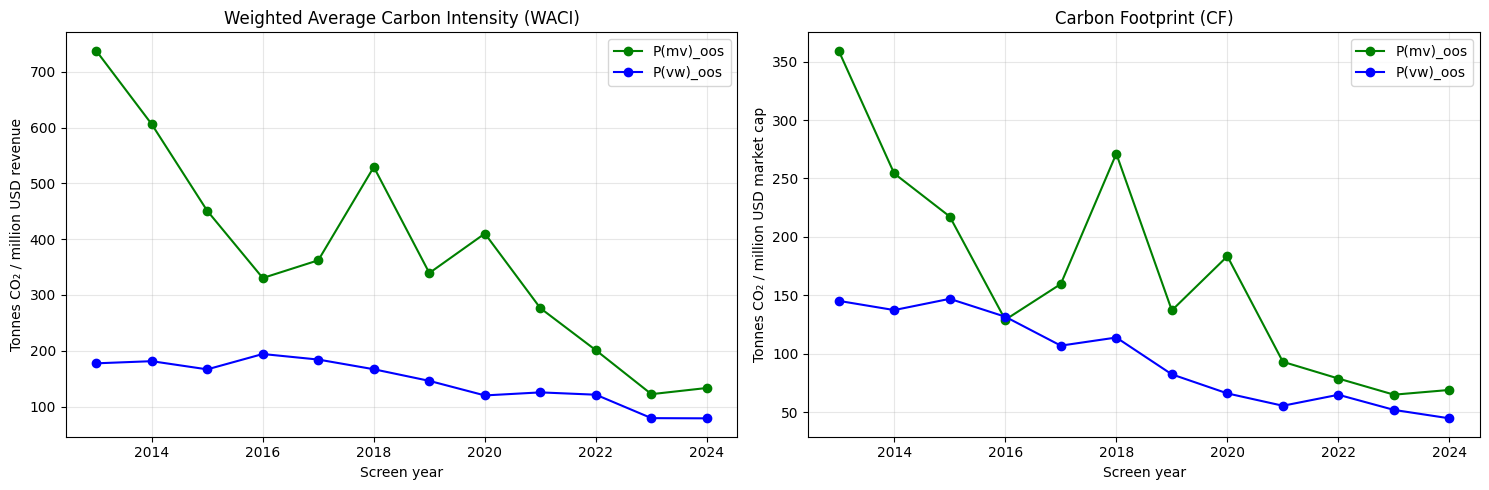

In [ ]:
# =============================================================================
# 1. Compute carbon intensity for all firms in investment set
# =============================================================================
date_cols_mv = sort_month_cols(get_time_cols(mv_clean))

carbon_intensity_by_year = {}  # {year: {isin: CI_i,Y}}

# Get all years where we have CO2 and revenue data
year_cols = sort_year_cols([c for c in co2_clean.columns if c.isdigit()])

for year_str in year_cols:
    year = int(year_str)
    if START_YEAR <= year <= END_YEAR:
        carbon_intensity_by_year[year] = {}
        
        for isin in co2_clean.index:
            co2_val = co2_clean.loc[isin, year_str] if year_str in co2_clean.columns else np.nan
            rev_val = rev_clean.loc[isin, year_str] if year_str in rev_clean.columns else np.nan
            
            if pd.notna(co2_val) and pd.notna(rev_val) and rev_val > 0:
                ci = co2_val / (rev_val / 1000.0)
                carbon_intensity_by_year[year][isin] = ci
        
# =============================================================================
# 2. Compute WACI for MVP portfolio
# =============================================================================

mvp_waci_by_year = {}

for year in range(START_YEAR, END_YEAR + 1):
    # Get weights for this year from weights_by_year
    year_weights = weights_by_year[weights_by_year["screen_year"] == year]
    
    if year_weights.empty:
        mvp_waci_by_year[year] = np.nan
        continue
    
    waci = 0.0
    for _, row in year_weights.iterrows():
        isin = row["ISIN"]
        weight = row["weight"]
        ci = carbon_intensity_by_year.get(year, {}).get(isin, 0.0)
        waci += weight * ci
    
    mvp_waci_by_year[year] = waci
# =============================================================================
# 3. Compute WACI for Value-Weighted portfolio
# =============================================================================

vw_waci_by_year = {}

for year in range(START_YEAR, END_YEAR + 1):
    # Get market caps for year-end
    year_end_dt = pd.Timestamp(f"{year}-12-31")

    closest_col = min(
        date_cols_mv,
        key=lambda c: abs(pd.Timestamp(c) - year_end_dt)
    )
    if abs(pd.Timestamp(closest_col) - year_end_dt) > pd.Timedelta(days=10):
        print(f"WARNING: {year} year-end cap data {closest_col} is >10 days from 12-31")
    
    # For VW, we use market caps at the rebalance date
    # We need to match this with the same investment universe
    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year)
        & (investment_set["investable_for_next_year"] == True),
        "ISIN"
    ].tolist()
    
    # Get December year-end market caps
    date_cols_mv = sort_month_cols(get_time_cols(mv_clean))
    year_end_col = [c for c in date_cols_mv if str(year) in c]
    
    if not year_end_col:
        vw_waci_by_year[year] = np.nan
        continue
    
    year_end_col = year_end_col[-1]  # Get the last one if multiple matches
    
    # Get market caps and compute weights
    mv_vals = mv_by_isin.loc[investable_isins, year_end_col].apply(pd.to_numeric, errors='coerce')
    mv_vals = mv_vals.dropna()
    
    total_mv = mv_vals.sum()
    
    if total_mv <= 0:
        vw_waci_by_year[year] = np.nan
        continue
    
    waci = 0.0
    for isin in mv_vals.index:
        weight = mv_vals[isin] / total_mv
        ci = carbon_intensity_by_year.get(year, {}).get(isin, np.nan)
        if np.isnan(ci):
            continue
        waci += weight * ci
    
    vw_waci_by_year[year] = waci
# =============================================================================
# 4. Identify top 10 carbon drivers
# =============================================================================

# Use the most recent year available
latest_year = max(carbon_intensity_by_year.keys())
print(f"Top 10 Carbon Drivers — {latest_year}")

ci_data = carbon_intensity_by_year[latest_year]

top_10 = sorted(
    [(isin, ci, isin_to_name.get(isin, "N/A")) for isin, ci in ci_data.items()],
    key=lambda x: x[1],
    reverse=True
)[:10]

for rank, (isin, ci, name) in enumerate(top_10, 1):
    print(f"  {rank}. {name} ({isin}): {ci:.1f}")

# =============================================================================
# 5. Summary table: WACI comparison
# =============================================================================

waci_summary = pd.DataFrame({
    "Year": sorted(mvp_waci_by_year.keys()),
    "MVP_WACI": [mvp_waci_by_year.get(y, np.nan) for y in sorted(mvp_waci_by_year.keys())],
    "VW_WACI":  [vw_waci_by_year.get(y, np.nan) for y in sorted(mvp_waci_by_year.keys())],
})

waci_summary["CI_Reduction_%"] = (
    (waci_summary["VW_WACI"] - waci_summary["MVP_WACI"]) / waci_summary["VW_WACI"] * 100
)

display(waci_summary)

# =============================================================================
# 6. Compute Carbon Footprint (CF) for MVP and VW
# =============================================================================
mvp_cf_by_year = {}
vw_cf_by_year = {}

# Get December market cap columns for lookup
date_cols_mv = sort_month_cols(get_time_cols(mv_clean))

for year in range(START_YEAR, END_YEAR + 1):
    year_str = str(year)
    
    # --- MVP Carbon Footprint ---
    # Assuming $1 Million USD invested: Vy = 1. Therefore o_i = (Weight * 1) / Cap_i
    year_weights = weights_by_year[weights_by_year["screen_year"] == year]
    if year_weights.empty:
        mvp_cf_by_year[year] = np.nan
    else:
        cf_mvp = 0.0
        for _, row in year_weights.iterrows():
            isin = row["ISIN"]
            weight = row["weight"]
            
            co2_val = co2_clean.loc[isin, year_str] if (isin in co2_clean.index and year_str in co2_clean.columns) else np.nan
            
            # Market cap at investment date (December of year)
            year_end_col = [c for c in date_cols_mv if str(year) in c and "-12" in c]
            cap_val = mv_by_isin.loc[isin, year_end_col[-1]] if (year_end_col and isin in mv_by_isin.index) else np.nan
            
            if pd.notna(co2_val) and pd.notna(cap_val) and cap_val > 0:
                cf_mvp += (weight / cap_val) * co2_val
                
        mvp_cf_by_year[year] = cf_mvp
        
    # --- VW Carbon Footprint ---
    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & 
        (investment_set["investable_for_next_year"] == True), "ISIN"
    ].tolist()
    
    year_end_col = [c for c in date_cols_mv if str(year) in c and "-12" in c]
    if not year_end_col or not investable_isins:
        vw_cf_by_year[year] = np.nan
        continue
        
    cap_vals = mv_by_isin.loc[investable_isins, year_end_col[-1]].apply(pd.to_numeric, errors='coerce').dropna()
    total_cap = cap_vals.sum()
    
    if total_cap > 0:
        cf_vw = 0.0
        for isin in cap_vals.index:
            co2_val = co2_clean.loc[isin, year_str] if (isin in co2_clean.index and year_str in co2_clean.columns) else np.nan
            if pd.notna(co2_val):
                cf_vw += (co2_val / total_cap)
        vw_cf_by_year[year] = cf_vw

# Add CF to the summary table
waci_summary["MVP_CF"] = [mvp_cf_by_year.get(y, np.nan) for y in waci_summary["Year"]]
waci_summary["VW_CF"] =  [vw_cf_by_year.get(y, np.nan) for y in waci_summary["Year"]]


# =============================================================================
# 7. Plot WACI and CF Comparisons
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# WACI Plot
ax1.plot(waci_summary["Year"], waci_summary["MVP_WACI"], marker='o', label="P(mv)_oos", color="green")
ax1.plot(waci_summary["Year"], waci_summary["VW_WACI"], marker='o', label="P(vw)_oos", color="blue")
ax1.set_title("Weighted Average Carbon Intensity (WACI)")
ax1.set_ylabel("Tonnes CO₂ / million USD revenue")
ax1.set_xlabel("Screen year")
ax1.legend()
ax1.grid(alpha=0.3)

# CF Plot
ax2.plot(waci_summary["Year"], waci_summary["MVP_CF"], marker='o', label="P(mv)_oos", color="green")
ax2.plot(waci_summary["Year"], waci_summary["VW_CF"], marker='o', label="P(vw)_oos", color="blue")
ax2.set_title("Carbon Footprint (CF)")
ax2.set_ylabel("Tonnes CO₂ / million USD market cap")
ax2.set_xlabel("Screen year")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "carbon_metrics_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.2 Carbon-Constrained MVP — P(mv)\_oos(0.5)

We extend the MVP with a carbon footprint constraint: the portfolio CF must not exceed 50 % of the unconstrained MVP CF.

The carbon footprint is $CF^{(p)}_Y = \sum_i (\alpha_{i,Y} / Cap_{i,Y}) \cdot E_{i,Y}$, giving a linear constraint:

$$\min_{\alpha_Y}\; \alpha_Y^\top \hat{\Sigma}_Y \alpha_Y \quad\text{s.t.}\quad \sum_i \frac{E_{i,Y}}{Cap_{i,Y}}\,\alpha_{i,Y} \leq 0.5 \times CF^{(mv)}_Y,\; \alpha_Y^\top e = 1,\; \alpha_{i,Y} \geq 0$$

Out-of-sample returns follow the same weight-drift procedure as Section 2.2.

 2013:  771 firms (0 w/o E or Cap) | var = 0.000382 | CF = 179.696612 (limit 179.696612, MVP 359.393223) | max_w = 0.0874
    slack vs CF limit: 0.0000  (0.0% of limit)
 2014:  811 firms (0 w/o E or Cap) | var = 0.000394 | CF = 127.139625 (limit 127.139625, MVP 254.279250) | max_w = 0.0876
    slack vs CF limit: 0.0000  (0.0% of limit)
 2015:  862 firms (0 w/o E or Cap) | var = 0.000414 | CF = 108.716655 (limit 108.716655, MVP 217.433309) | max_w = 0.0868
    slack vs CF limit: 0.0000  (0.0% of limit)
 2016:  895 firms (0 w/o E or Cap) | var = 0.000453 | CF = 64.516041 (limit 64.516041, MVP 129.032081) | max_w = 0.0869
    slack vs CF limit: -0.0000  (-0.0% of limit)
 2017:  931 firms (0 w/o E or Cap) | var = 0.000454 | CF = 79.770730 (limit 79.827664, MVP 159.655329) | max_w = 0.0714
    slack vs CF limit: 0.0569  (0.1% of limit)
 2018:  984 firms (0 w/o E or Cap) | var = 0.000351 | CF = 135.607323 (limit 135.607323, MVP 271.214646) | max_w = 0.0505
    slack vs CF limit: 0.0000  (0.0

,Portfolio,Ann. Return,Ann. Volatility,Sharpe Ratio,Min Monthly Ret.,Max Monthly Ret.
0,P(mv)_oos,7.36%,11.58%,0.485,-11.77%,10.74%
1,P(mv)_oos(0.5),7.32%,11.52%,0.484,-11.27%,10.87%


,Year,MVP_WACI,MVP05_WACI,MVP_CF,MVP05_CF,WACI_change_%,CF_change_%
0,2013,737.7064,345.1135,359.3932,179.6966,-53.2180,-50.0000
1,2014,605.9852,287.1366,254.2792,127.1396,-52.6166,-50.0000
2,2015,450.7553,206.8527,217.4333,108.7167,-54.1098,-50.0000
3,2016,330.2945,148.0669,129.0321,64.5160,-55.1712,-50.0000
4,2017,362.0891,175.1949,159.6553,79.7707,-51.6155,-50.0357
5,2018,529.2495,245.1701,271.2146,135.6073,-53.6759,-50.0000
6,2019,339.2641,153.4272,137.0790,68.5395,-54.7765,-50.0000
7,2020,410.0104,196.6740,183.4212,91.6071,-52.0319,-50.0564
8,2021,276.2180,159.3178,93.0609,46.5305,-42.3217,-50.0000
9,2022,200.8267,84.4282,78.7161,39.3581,-57.9597,-50.0000


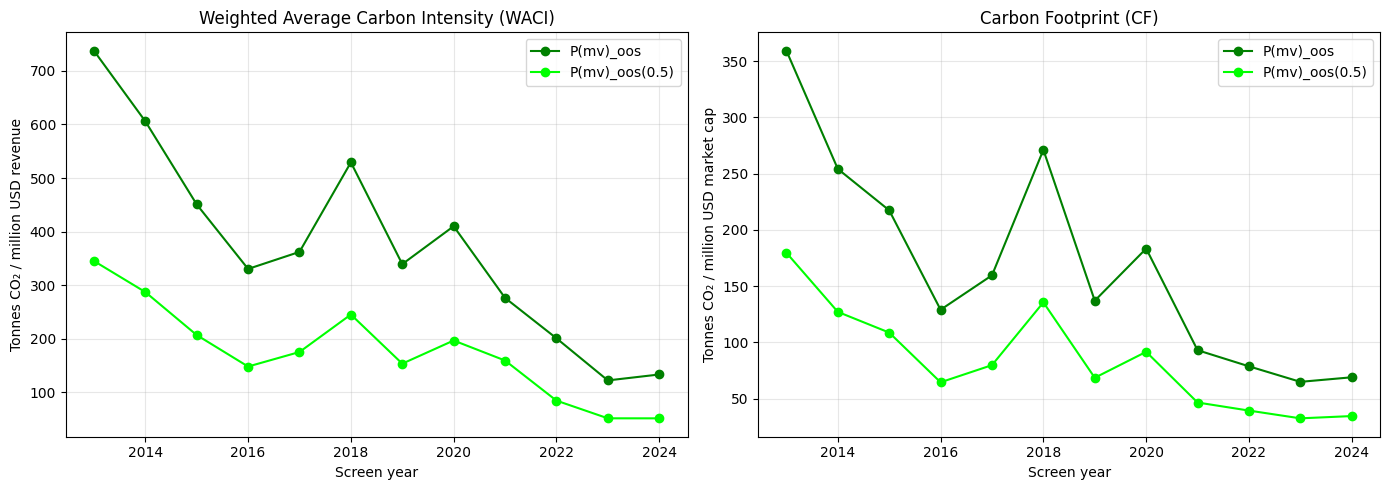

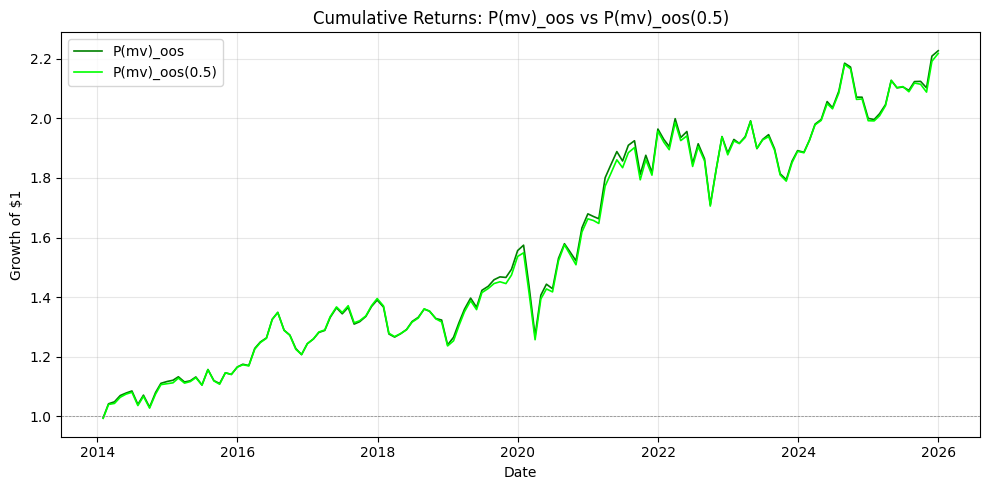

,w_mvp_avg,w_mvp05_avg,weight_drop,CI_avg,NAME,Country,Region
ISIN,,,,,,,
US8425871071,2.63%,0.98%,1.65%,"4,754.9",SOUTHERN,US,AMER
US26441C2044,0.83%,0.11%,0.72%,"4,304.1",DUKE ENERGY,US,AMER
US1258961002,0.88%,0.20%,0.68%,"2,291.8",CMS ENERGY,US,AMER
US3379321074,1.98%,1.49%,0.49%,"1,940.3",FIRSTENERGY,US,AMER
US92939U1060,0.66%,0.17%,0.49%,"3,945.9",WEC ENERGY GROUP,US,AMER
US4198701009,0.73%,0.38%,0.35%,"1,426.5",HAWAIIAN ELECTRIC INDS.,US,AMER
US69351T1060,0.44%,0.25%,0.19%,"3,370.6",PPL,US,AMER
US65473P1057,0.23%,0.04%,0.19%,"2,106.2",NISOURCE,US,AMER
US25746U1097,0.43%,0.25%,0.18%,"2,521.2",DOMINION ENERGY,US,AMER



Top 10 countries by total weight drop (P(mv)_oos minus P(mv)_oos(0.5)):
Country
US     0.13%
ES     0.11%
IE     0.06%
DE     0.03%
NL     0.01%
NO     0.01%
PT    -0.00%
IL    -0.00%
IT    -0.00%
SE    -0.01%

Weight drop by region:
Region
AMER    -0.12%
EUR     -0.77%

Average CI of the 10 most penalised firms : 3,066.2 t CO2 / M$ revenue
Average CI of the 10 most favoured firms  : 72.9 t CO2 / M$ revenue


In [ ]:
# =============================================================================
# 1. Carbon-footprint-constrained MVP solver
# =============================================================================

CF_REDUCTION = 0.50  # target: CF <= 50% of unconstrained MVP CF


def solve_cf_constrained_mvp(cov, cf_coef, cf_limit):
    n = cov.shape[0]
    w = cp.Variable(n)

    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov))),
        [
            cp.sum(w) == 1,
            w >= 0,
            cf_coef @ w <= cf_limit,
        ],
    )

    prob.solve(solver=cp.OSQP, verbose=False)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"CF-constrained MVP failed: {prob.status}")

    weights = np.clip(np.array(w.value).flatten(), 0, None)
    return weights / weights.sum()


# =============================================================================
# 2. Main loop — solve for each screen year Y
# =============================================================================

mvp05_weights_rows = []
mvp05_return_rows  = []
mvp05_summary_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1
    year_str = str(year)

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN",
    ].tolist()
    if not investable_isins:
        print(f"{year}: skipped — no investable firms.")
        continue

    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year, window_years=WINDOW_YEARS)
    if not window_cols:
        print(f"{year}: skipped — no trailing window.")
        continue

    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)
    if not valid_isins:
        print(f"{year}: skipped — no complete-case assets.")
        continue

    # December-end market cap column for year Y
    year_end_cols = [c for c in mv_month_cols if str(year) in c and "-12" in c]
    if not year_end_cols:
        print(f"{year}: skipped — no December market cap column.")
        continue
    year_end_col = year_end_cols[-1]

    # Build the constraint vector  E_i / Cap_i  (zero if data missing)
    cf_coef = np.zeros(len(valid_isins))
    n_missing = 0
    for k, isin in enumerate(valid_isins):
        co2_val = co2_clean.loc[isin, year_str] if (isin in co2_clean.index and year_str in co2_clean.columns) else np.nan
        cap_val = mv_by_isin.loc[isin, year_end_col] if isin in mv_by_isin.index else np.nan
        try:
            cap_val = float(cap_val)
        except Exception:
            cap_val = np.nan
        if pd.notna(co2_val) and pd.notna(cap_val) and cap_val > 0:
            cf_coef[k] = co2_val / cap_val
        else:
            n_missing += 1

    # Target: 50 % of unconstrained MVP carbon footprint
    cf_mvp_target = mvp_cf_by_year.get(year, np.nan)
    if np.isnan(cf_mvp_target) or cf_mvp_target <= 0:
        print(f"{year}: skipped — missing MVP CF.")
        continue

    cf_limit = (1.0 - CF_REDUCTION) * cf_mvp_target

    try:
        w_05 = solve_cf_constrained_mvp(cov, cf_coef, cf_limit)
    except RuntimeError as e:
        print(f"{year}: {e}")
        continue

    realized_cf = float(cf_coef @ w_05)
    port_var    = float(w_05.T @ cov @ w_05)

    print(
        f" {year}: {len(valid_isins):>4} firms ({n_missing} w/o E or Cap) | "
        f"var = {port_var:.6f} | "
        f"CF = {realized_cf:.6f} (limit {cf_limit:.6f}, MVP {cf_mvp_target:.6f}) | "
        f"max_w = {w_05.max():.4f}"
    )
    # ---- Sanity check: is the CF constraint binding? ----
    slack_05 = cf_limit - realized_cf
    print(f"    slack vs CF limit: {slack_05:.4f}  ({slack_05 / cf_limit * 100:.1f}% of limit)")

    for isin, w in zip(valid_isins, w_05):
        mvp05_weights_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "ISIN":            isin,
            "weight":          w,
        })

    mvp05_summary_rows.append({
        "screen_year":     year,
        "investment_year": investment_year,
        "n_assets":        len(valid_isins),
        "port_variance":   port_var,
        "realized_cf":     realized_cf,
        "cf_limit":        cf_limit,
        "cf_mvp_target":   cf_mvp_target,
        "max_weight":      float(w_05.max()),
    })

    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue

    current_w = pd.Series(w_05, index=valid_isins)

    for col in inv_cols:
        month_rets = ri_ret_by_isin.reindex(valid_isins)[col].apply(pd.to_numeric, errors="coerce")
        valid_mask = month_rets.notna()
        w_m = current_w[valid_mask]
        r_m = month_rets[valid_mask]
        rp  = float((w_m / w_m.sum() * r_m).sum()) if w_m.sum() > 1e-8 else 0.0

        mvp05_return_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "date":            pd.Timestamp(col),
            "Rp_mvp05":        rp,
        })

        new_w = current_w.copy()
        new_w[valid_mask] = current_w[valid_mask] * (1.0 + month_rets[valid_mask])
        if new_w.sum() > 1e-8:
            current_w = new_w / new_w.sum()

# =============================================================================
# 3. Collect and save
# =============================================================================

mvp05_weights_by_year = pd.DataFrame(mvp05_weights_rows)
mvp05_monthly_returns = pd.DataFrame(mvp05_return_rows).sort_values("date").reset_index(drop=True)
mvp05_summary_by_year = pd.DataFrame(mvp05_summary_rows)

mvp05_weights_by_year.to_csv(OUT_DIR / "mvp05_weights_by_year.csv", index=False)
mvp05_monthly_returns.to_csv(OUT_DIR / "mvp05_monthly_returns.csv", index=False)
mvp05_summary_by_year.to_csv(OUT_DIR / "mvp05_summary_by_year.csv", index=False)

print(f"\nP(mv)_oos(0.5): {len(mvp05_monthly_returns)} monthly observations.")

# =============================================================================
# Performance comparison
# =============================================================================


mvp05_returns_idx = (
    mvp05_monthly_returns[["date", "Rp_mvp05"]]
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .sort_values("date")
    .set_index("date")
)["Rp_mvp05"]

common_idx     = compare_df.index.intersection(mvp05_returns_idx.index)
mvp_aligned    = compare_df.loc[common_idx, "Rp_mvp"]
mvp05_aligned  = mvp05_returns_idx.loc[common_idx]


stats_mvp   = summary_stats(mvp_aligned,   "P(mv)_oos",      rf_monthly=rf_monthly_avg)
stats_mvp05 = summary_stats(mvp05_aligned, "P(mv)_oos(0.5)", rf_monthly=rf_monthly_avg)

perf = pd.DataFrame([stats_mvp, stats_mvp05])

perf_mv = perf[
    ["portfolio", "ann_mean_return", "ann_volatility",
     "sharpe_ratio", "min_monthly_return", "max_monthly_return"]
].copy()
perf_mv.columns = [
    "Portfolio", "Ann. Return", "Ann. Volatility",
    "Sharpe Ratio", "Min Monthly Ret.", "Max Monthly Ret."
]
for col in ["Ann. Return", "Ann. Volatility", "Min Monthly Ret.", "Max Monthly Ret."]:
    perf_mv[col] = perf_mv[col].apply(lambda x: f"{x:.2%}")
perf_mv["Sharpe Ratio"] = perf_mv["Sharpe Ratio"].apply(lambda x: f"{x:.3f}")

display(perf_mv)

perf.to_csv(OUT_DIR / "mvp_vs_mvp05_performance_summary.csv", index=False)

# =============================================================================
# WACI and CF for P(mv)_oos(0.5)
# =============================================================================

mvp05_waci_by_year = {}
mvp05_cf_by_year   = {}

for year in range(START_YEAR, END_YEAR + 1):
    year_str = str(year)
    yw = mvp05_weights_by_year[mvp05_weights_by_year["screen_year"] == year]
    if yw.empty:
        mvp05_waci_by_year[year] = np.nan
        mvp05_cf_by_year[year]   = np.nan
        continue

    year_end_cols = [c for c in mv_month_cols if str(year) in c and "-12" in c]
    year_end_col  = year_end_cols[-1] if year_end_cols else None

    waci = 0.0
    cf   = 0.0
    for _, row in yw.iterrows():
        isin = row["ISIN"]
        w    = row["weight"]

        # WACI
        ci   = carbon_intensity_by_year.get(year, {}).get(isin, 0.0)
        waci += w * ci

        # CF
        if year_end_col is None:
            continue
        co2_val = co2_clean.loc[isin, year_str] if (isin in co2_clean.index and year_str in co2_clean.columns) else np.nan
        cap_val = mv_by_isin.loc[isin, year_end_col] if isin in mv_by_isin.index else np.nan
        try:
            cap_val = float(cap_val)
        except Exception:
            cap_val = np.nan
        if pd.notna(co2_val) and pd.notna(cap_val) and cap_val > 0:
            cf += (w / cap_val) * co2_val

    mvp05_waci_by_year[year] = waci
    mvp05_cf_by_year[year]   = cf

# =============================================================================
# Build comparison table
# =============================================================================

years = sorted(set(mvp_waci_by_year) & set(mvp05_waci_by_year))
carbon_compare = pd.DataFrame({
    "Year":       years,
    "MVP_WACI":   [mvp_waci_by_year.get(y, np.nan)   for y in years],
    "MVP05_WACI": [mvp05_waci_by_year.get(y, np.nan) for y in years],
    "MVP_CF":     [mvp_cf_by_year.get(y, np.nan)     for y in years],
    "MVP05_CF":   [mvp05_cf_by_year.get(y, np.nan)   for y in years],
})

carbon_compare["WACI_change_%"] = (
    (carbon_compare["MVP05_WACI"] - carbon_compare["MVP_WACI"]) / carbon_compare["MVP_WACI"] * 100
)
carbon_compare["CF_change_%"] = (
    (carbon_compare["MVP05_CF"] - carbon_compare["MVP_CF"]) / carbon_compare["MVP_CF"] * 100
)

display(carbon_compare.round(4))
carbon_compare.to_csv(OUT_DIR / "mvp_vs_mvp05_carbon.csv", index=False)

# =============================================================================
# Plot WACI and CF
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(carbon_compare["Year"], carbon_compare["MVP_WACI"],   marker="o", label="P(mv)_oos", color="green")
ax1.plot(carbon_compare["Year"], carbon_compare["MVP05_WACI"], marker="o", label="P(mv)_oos(0.5)", color="#00ff00")
ax1.set_title("Weighted Average Carbon Intensity (WACI)")
ax1.set_ylabel("Tonnes CO₂ / million USD revenue")
ax1.set_xlabel("Screen year")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(carbon_compare["Year"], carbon_compare["MVP_CF"],   marker="o", label="P(mv)_oos", color="green")
ax2.plot(carbon_compare["Year"], carbon_compare["MVP05_CF"], marker="o", label="P(mv)_oos(0.5)", color="#00ff00")
ax2.set_title("Carbon Footprint (CF)")
ax2.set_ylabel("Tonnes CO₂ / million USD market cap")
ax2.set_xlabel("Screen year")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "mvp_vs_mvp05_carbon_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# Cumulative returns
# =============================================================================

mvp_cum   = (1.0 + mvp_aligned).cumprod()
mvp05_cum = (1.0 + mvp05_aligned).cumprod()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mvp_cum.index,   mvp_cum,   linewidth=1.2, label="P(mv)_oos", color="green")
ax.plot(mvp05_cum.index, mvp05_cum, linewidth=1.2, label="P(mv)_oos(0.5)", color="#00ff00")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.5)
ax.set_title("Cumulative Returns: P(mv)_oos vs P(mv)_oos(0.5)")
ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "mvp_vs_mvp05_cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# Average weights per ISIN across all screen years (zero-fill for missing)
# =============================================================================

mvp_avg = (
    weights_by_year.groupby("ISIN")["weight"].mean().rename("w_mvp_avg")
)
mvp05_avg = (
    mvp05_weights_by_year.groupby("ISIN")["weight"].mean().rename("w_mvp05_avg")
)
weights_panel = pd.concat([mvp_avg, mvp05_avg], axis=1).fillna(0.0)
weights_panel["weight_drop"] = weights_panel["w_mvp_avg"] - weights_panel["w_mvp05_avg"]

# Average CI per ISIN across years for which data exists
ci_long = []
for y, d in carbon_intensity_by_year.items():
    for isin, ci in d.items():
        ci_long.append({"ISIN": isin, "year": y, "CI": ci})
ci_avg = pd.DataFrame(ci_long).groupby("ISIN")["CI"].mean().rename("CI_avg")

# Static info: name, country, region (no sector column in the static file)
static_full = clean_headers(pd.read_csv(RAW_DIR / STATIC_FILE))
isin_col_s    = next(c for c in static_full.columns if c.upper() == "ISIN")
name_col_s    = next(c for c in static_full.columns if c.upper() == "NAME")
country_col_s = next((c for c in static_full.columns if c.upper() == "COUNTRY"), None)
region_col_s  = next((c for c in static_full.columns if c.upper() == "REGION"),  None)

lookup_cols = [isin_col_s, name_col_s]
if country_col_s: lookup_cols.append(country_col_s)
if region_col_s:  lookup_cols.append(region_col_s)

static_lookup = (
    static_full[lookup_cols]
    .drop_duplicates(subset=[isin_col_s])
    .set_index(isin_col_s)
)

panel = weights_panel.join(ci_avg, how="left").join(static_lookup, how="left")
panel = panel.sort_values("weight_drop", ascending=False)

# =============================================================================
# Top 10 firms by largest weight drop
# =============================================================================

top10 = panel.head(10).copy()
top10_disp = top10.copy()
top10_disp["w_mvp_avg"]   = top10_disp["w_mvp_avg"].apply(lambda x: f"{x:.2%}")
top10_disp["w_mvp05_avg"] = top10_disp["w_mvp05_avg"].apply(lambda x: f"{x:.2%}")
top10_disp["weight_drop"] = top10_disp["weight_drop"].apply(lambda x: f"{x:.2%}")
top10_disp["CI_avg"]      = top10_disp["CI_avg"].apply(lambda x: f"{x:,.1f}" if pd.notna(x) else "n/a")

display(top10_disp)

panel.to_csv(OUT_DIR / "mvp_vs_mvp05_weight_changes.csv")

# =============================================================================
# Aggregate weight drop by country and by region
# =============================================================================

if country_col_s is not None:
    by_country = (
        panel.groupby(country_col_s)["weight_drop"].sum()
        .sort_values(ascending=False).head(10)
    )
    print("\nTop 10 countries by total weight drop (P(mv)_oos minus P(mv)_oos(0.5)):")
    print(by_country.apply(lambda x: f"{x:.2%}").to_string())

if region_col_s is not None:
    by_region = panel.groupby(region_col_s)["weight_drop"].sum().sort_values(ascending=False)
    print("\nWeight drop by region:")
    print(by_region.apply(lambda x: f"{x:.2%}").to_string())

# =============================================================================
# Carbon intensity of penalised vs favoured names
# =============================================================================

penalised = panel.head(10)["CI_avg"].dropna()
favoured  = panel.tail(10)["CI_avg"].dropna()

print(f"\nAverage CI of the 10 most penalised firms : {penalised.mean():,.1f} t CO2 / M$ revenue")
print(f"Average CI of the 10 most favoured firms  : {favoured.mean():,.1f} t CO2 / M$ revenue")

## 3.3 Tracking-Error Minimization — P(vw)\_oos(0.5)

We minimise tracking error to the VW benchmark subject to a 50 % carbon footprint reduction:

$$\min_{\alpha_Y}\; (\alpha_Y - \alpha^{(vw)}_Y)^\top \hat{\Sigma}_Y (\alpha_Y - \alpha^{(vw)}_Y) \quad\text{s.t.}\quad CF^{(p)}_Y \leq 0.5 \times CF^{(vw)}_Y,\; \alpha_Y^\top e = 1,\; \alpha_{i,Y} \geq 0$$

  2013:  771 firms (0 missing E/Cap) | TE = 0.000158 | CF = 72.615970 (limit 72.616515, VW 145.233031) | max_w = 0.0234
  2014:  811 firms (0 missing E/Cap) | TE = 0.000160 | CF = 68.659851 (limit 68.669999, VW 137.339999) | max_w = 0.0289
  2015:  862 firms (0 missing E/Cap) | TE = 0.000155 | CF = 73.486520 (limit 73.486941, VW 146.973882) | max_w = 0.0269
  2016:  895 firms (0 missing E/Cap) | TE = 0.000161 | CF = 65.821577 (limit 65.822777, VW 131.645555) | max_w = 0.0262
  2017:  931 firms (0 missing E/Cap) | TE = 0.000166 | CF = 53.447332 (limit 53.447802, VW 106.895604) | max_w = 0.0307
  2018:  984 firms (0 missing E/Cap) | TE = 0.000169 | CF = 56.921199 (limit 56.921456, VW 113.842912) | max_w = 0.0299
  2019: 1073 firms (0 missing E/Cap) | TE = 0.000114 | CF = 41.158768 (limit 41.158768, VW 82.317536) | max_w = 0.0385
  2020: 1115 firms (0 missing E/Cap) | TE = 0.000125 | CF = 33.000327 (limit 33.001280, VW 66.002559) | max_w = 0.0589
  2021: 1148 firms (0 missing E/Cap) | TE 

,Portfolio,Ann. Return,Ann. Volatility,Sharpe Ratio,Min Monthly Ret.,Max Monthly Ret.
0,P(vw)_oos,11.61%,14.17%,0.696,-13.07%,12.84%
1,P(vw)_oos(0.5),11.57%,14.17%,0.693,-13.05%,12.88%


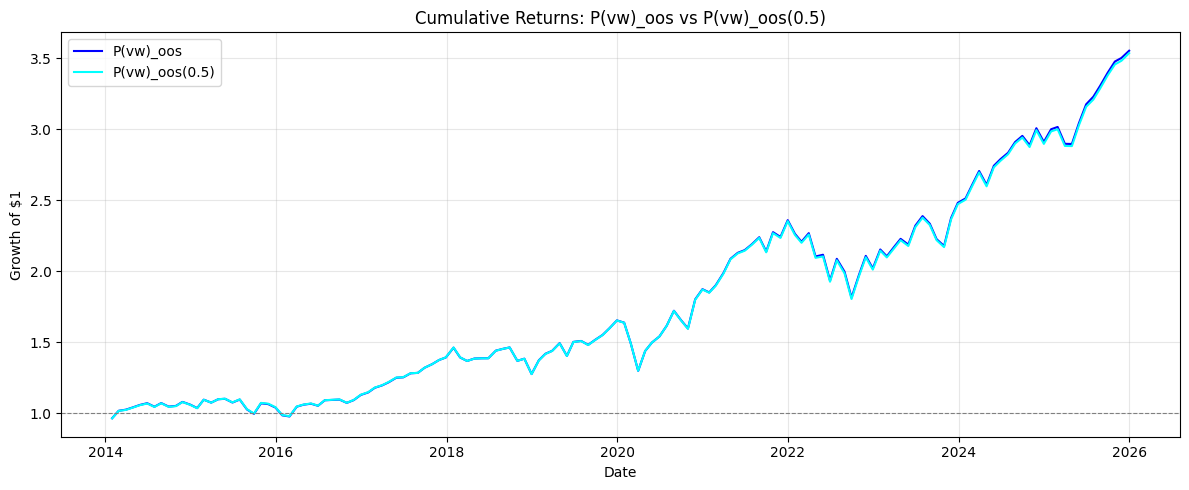

,Year,VW_WACI,TE05_WACI,VW_CF,TE05_CF,WACI_change_%,CF_change_%
0,2013,177.3971,103.1972,145.2330,72.6160,-41.8270,-50.0004
1,2014,181.2458,107.4696,137.3400,68.6599,-40.7051,-50.0074
2,2015,166.5857,99.2915,146.9739,73.4865,-40.3962,-50.0003
3,2016,194.0923,118.6938,131.6456,65.8216,-38.8467,-50.0009
4,2017,184.1484,110.5364,106.8956,53.4473,-39.9742,-50.0004
5,2018,166.7857,96.3710,113.8429,56.9212,-42.2187,-50.0002
6,2019,145.9508,85.6229,82.3175,41.1588,-41.3344,-50.0000
7,2020,119.8571,70.6875,66.0026,33.0003,-41.0235,-50.0014
8,2021,125.3154,78.0456,55.4329,27.7164,-37.7206,-50.0000
9,2022,121.1457,77.3007,64.8368,32.4184,-36.1920,-50.0000


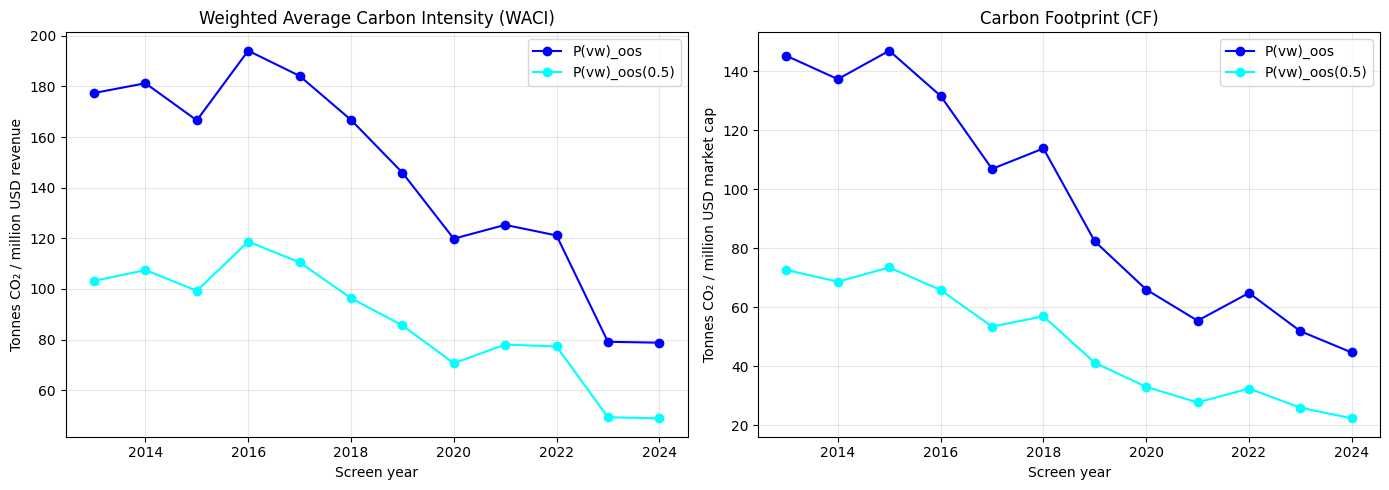

In [ ]:
# =============================================================================
# 1. Tracking-error-constrained solver
# =============================================================================

def solve_te_constrained(cov, w_vw, cf_coef, cf_limit):
    n    = cov.shape[0]
    w    = cp.Variable(n)
    diff = w - w_vw   # active weights vs benchmark

    prob = cp.Problem(
        cp.Minimize(cp.quad_form(diff, cp.psd_wrap(cov))),
        [
            cp.sum(w) == 1,
            w >= 0,
            cf_coef @ w <= cf_limit,
        ],
    )
    prob.solve(solver=cp.OSQP, verbose=False, max_iter=10_000)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"TE-constrained solver failed: {prob.status}")

    weights = np.clip(np.array(w.value).flatten(), 0, None)
    return weights / weights.sum()


# =============================================================================
# 2. Main loop — solve P(vw)_oos(0.5) for each screen year Y
# =============================================================================

te05_weights_rows = []
te05_return_rows  = []
te05_summary_rows = []


for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1
    year_str        = str(year)

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN",
    ].tolist()
    if not investable_isins:
        print(f"  {year}: skipped — no investable firms.")
        continue

    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year, window_years=WINDOW_YEARS)
    if not window_cols:
        print(f"  {year}: skipped — no trailing window.")
        continue

    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)
    if not valid_isins:
        print(f"  {year}: skipped — no complete-case assets.")
        continue

    # December year-end market cap column
    year_end_col = get_december_col(mv_month_cols, year)
    if year_end_col is None:
        print(f"  {year}: skipped — no December market cap column.")
        continue

    # Value-weighted benchmark weights over valid_isins (same universe as cov)
    cap_series = (
        mv_by_isin.reindex(valid_isins)[year_end_col]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .clip(lower=0.0)
    )
    total_cap_valid = cap_series.sum()
    if total_cap_valid <= 0:
        print(f"  {year}: skipped — zero total market cap.")
        continue
    w_vw_arr = (cap_series / total_cap_valid).values  # shape (N,)

    # Carbon footprint of the VW benchmark:
    #   CF^(P(vw))_Y = (1 / Cap_Y) * sum_i E_{i,Y}
    all_caps = (
        mv_by_isin.reindex(investable_isins)[year_end_col]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
    )
    total_cap_all = all_caps.sum()
    if total_cap_all <= 0:
        print(f"  {year}: skipped — zero total cap for VW CF.")
        continue

    cf_vw_benchmark = 0.0
    for isin in investable_isins:
        co2_val = (
            co2_clean.loc[isin, year_str]
            if (isin in co2_clean.index and year_str in co2_clean.columns)
            else np.nan
        )
        if pd.notna(co2_val):
            cf_vw_benchmark += co2_val / total_cap_all

    if cf_vw_benchmark <= 0:
        print(f"  {year}: skipped — VW CF is zero or missing.")
        continue

    cf_limit = 0.5 * cf_vw_benchmark

    # Carbon constraint vector: cf_coef[k] = E_{i,Y} / Cap_{i,Y}
    cf_coef = np.zeros(len(valid_isins))
    n_missing_carbon = 0
    for k, isin in enumerate(valid_isins):
        co2_val = (
            co2_clean.loc[isin, year_str]
            if (isin in co2_clean.index and year_str in co2_clean.columns)
            else np.nan
        )
        cap_val = mv_by_isin.loc[isin, year_end_col] if isin in mv_by_isin.index else np.nan
        try:
            cap_val = float(cap_val)
        except Exception:
            cap_val = np.nan
        if pd.notna(co2_val) and pd.notna(cap_val) and cap_val > 0:
            cf_coef[k] = co2_val / cap_val
        else:
            n_missing_carbon += 1

    # Solve
    try:
        w_te = solve_te_constrained(cov, w_vw_arr, cf_coef, cf_limit)
    except RuntimeError as e:
        print(f"  {year}: solver error — {e}")
        continue

    realized_cf = float(cf_coef @ w_te)
    realized_te = float(np.sqrt((w_te - w_vw_arr) @ cov @ (w_te - w_vw_arr)))

    print(
        f"  {year}: {len(valid_isins):>4} firms ({n_missing_carbon} missing E/Cap) | "
        f"TE = {realized_te:.6f} | "
        f"CF = {realized_cf:.6f} (limit {cf_limit:.6f}, VW {cf_vw_benchmark:.6f}) | "
        f"max_w = {w_te.max():.4f}"
    )

    for isin, w in zip(valid_isins, w_te):
        te05_weights_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "ISIN":            isin,
            "weight":          w,
        })

    te05_summary_rows.append({
        "screen_year":      year,
        "investment_year":  investment_year,
        "n_assets":         len(valid_isins),
        "n_missing_carbon": n_missing_carbon,
        "tracking_error":   realized_te,
        "realized_CF":      realized_cf,
        "cf_limit":         cf_limit,
        "vw_cf_benchmark":  cf_vw_benchmark,
        "max_weight":       float(w_te.max()),
    })

    # Out-of-sample monthly returns with weight drift
    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue

    current_weights = pd.Series(w_te, index=valid_isins)

    for col in inv_cols:
        month_rets = (
            ri_ret_by_isin.reindex(valid_isins)[col]
            .apply(pd.to_numeric, errors="coerce")
        )
        valid_mask   = month_rets.notna()
        w_this_month = current_weights[valid_mask]
        r_this_month = month_rets[valid_mask]

        if w_this_month.sum() > 1e-8:
            w_norm = w_this_month / w_this_month.sum()
            rp     = float((w_norm * r_this_month).sum())
        else:
            rp = 0.0

        te05_return_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "date":            pd.Timestamp(col),
            "Rp_te05":         rp,
        })

        # Weight drift
        new_weights = current_weights.copy()
        new_weights[valid_mask] = current_weights[valid_mask] * (1.0 + month_rets[valid_mask])
        total_w = new_weights.sum()
        if total_w > 1e-8:
            current_weights = new_weights / total_w

# Assemble DataFrames
te05_weights_by_year = pd.DataFrame(te05_weights_rows)
te05_monthly_returns = pd.DataFrame(te05_return_rows).sort_values("date").reset_index(drop=True)
te05_year_summary    = pd.DataFrame(te05_summary_rows)

print(f"\nP(vw)_oos(0.5) solved for {len(te05_summary_rows)} years.")
print(f"Total monthly return observations: {len(te05_monthly_returns)}")

# =============================================================================
# 1. Performance summary — P(vw)_oos vs P(vw)_oos(0.5)
# =============================================================================

te05_returns_idx = (
    te05_monthly_returns[["date", "Rp_te05"]]
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .sort_values("date")
    .set_index("date")
)["Rp_te05"]

vw_returns_idx = compare_df["Rp_vw"]   # from Section 2.3

common_idx_te = vw_returns_idx.index.intersection(te05_returns_idx.index)
vw_aligned_te = vw_returns_idx.loc[common_idx_te]
te05_aligned  = te05_returns_idx.loc[common_idx_te]

stats_vw   = summary_stats(vw_aligned_te,  "P(vw)_oos",      rf_monthly=rf_monthly_avg)
stats_te05 = summary_stats(te05_aligned,   "P(vw)_oos(0.5)", rf_monthly=rf_monthly_avg)

perf_te = pd.DataFrame([stats_vw, stats_te05])

display_te = perf_te[
    ["portfolio", "ann_mean_return", "ann_volatility",
     "sharpe_ratio", "min_monthly_return", "max_monthly_return"]
].copy()
display_te.columns = [
    "Portfolio", "Ann. Return", "Ann. Volatility",
    "Sharpe Ratio", "Min Monthly Ret.", "Max Monthly Ret."
]
for col in ["Ann. Return", "Ann. Volatility", "Min Monthly Ret.", "Max Monthly Ret."]:
    display_te[col] = display_te[col].apply(lambda x: f"{x:.2%}")
display_te["Sharpe Ratio"] = display_te["Sharpe Ratio"].apply(lambda x: f"{x:.3f}")

display(display_te)
perf_te.to_csv(OUT_DIR / "vw_vs_te05_performance_summary.csv", index=False)

# =============================================================================
# 2. Cumulative return plot
# =============================================================================

cum_vw   = (1 + vw_aligned_te).cumprod()
cum_te05 = (1 + te05_aligned).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_vw.index,   cum_vw.values,   label="P(vw)_oos",    color="blue")
ax.plot(cum_te05.index, cum_te05.values, label="P(vw)_oos(0.5)", color="#00ffff")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Cumulative Returns: P(vw)_oos vs P(vw)_oos(0.5)")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "vw_vs_te05_cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# 3. WACI and CF for P(vw)_oos(0.5)
# =============================================================================

te05_waci_by_year = {}
te05_cf_by_year   = {}

for year in range(START_YEAR, END_YEAR + 1):
    year_str = str(year)
    yw = te05_weights_by_year[te05_weights_by_year["screen_year"] == year]
    if yw.empty:
        te05_waci_by_year[year] = np.nan
        te05_cf_by_year[year]   = np.nan
        continue

    year_end_col = get_december_col(mv_month_cols, year)
    if year_end_col is None:
        te05_waci_by_year[year] = np.nan
        te05_cf_by_year[year]   = np.nan
        continue

    waci = 0.0
    cf   = 0.0
    for _, row in yw.iterrows():
        isin = row["ISIN"]
        w    = row["weight"]

        ci = carbon_intensity_by_year.get(year, {}).get(isin, np.nan)
        if pd.notna(ci):
            waci += w * ci

        co2_val = (
            co2_clean.loc[isin, year_str]
            if (isin in co2_clean.index and year_str in co2_clean.columns)
            else np.nan
        )
        cap_val = mv_by_isin.loc[isin, year_end_col] if isin in mv_by_isin.index else np.nan
        try:
            cap_val = float(cap_val)
        except Exception:
            cap_val = np.nan
        if pd.notna(co2_val) and pd.notna(cap_val) and cap_val > 0:
            cf += (w / cap_val) * co2_val

    te05_waci_by_year[year] = waci
    te05_cf_by_year[year]   = cf

# =============================================================================
# 4. Carbon comparison table + plot
# =============================================================================

years_te = sorted(set(vw_waci_by_year) & set(te05_waci_by_year))

carbon_te = pd.DataFrame({
    "Year":      years_te,
    "VW_WACI":   [vw_waci_by_year.get(y, np.nan)   for y in years_te],
    "TE05_WACI": [te05_waci_by_year.get(y, np.nan) for y in years_te],
    "VW_CF":     [vw_cf_by_year.get(y, np.nan)     for y in years_te],
    "TE05_CF":   [te05_cf_by_year.get(y, np.nan)   for y in years_te],
})
carbon_te["WACI_change_%"] = (carbon_te["TE05_WACI"] - carbon_te["VW_WACI"]) / carbon_te["VW_WACI"] * 100
carbon_te["CF_change_%"]   = (carbon_te["TE05_CF"]   - carbon_te["VW_CF"])   / carbon_te["VW_CF"]   * 100

display(carbon_te.round(4))
carbon_te.to_csv(OUT_DIR / "vw_vs_te05_carbon.csv", index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(carbon_te["Year"], carbon_te["VW_WACI"],   marker="o", label="P(vw)_oos",      color="blue")
ax1.plot(carbon_te["Year"], carbon_te["TE05_WACI"], marker="o", label="P(vw)_oos(0.5)", color="#00ffff")
ax1.set_title("Weighted Average Carbon Intensity (WACI)")
ax1.set_ylabel("Tonnes CO₂ / million USD revenue")
ax1.set_xlabel("Screen year")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(carbon_te["Year"], carbon_te["VW_CF"],   marker="o", label="P(vw)_oos",      color="blue")
ax2.plot(carbon_te["Year"], carbon_te["TE05_CF"], marker="o", label="P(vw)_oos(0.5)", color="#00ffff")
ax2.set_title("Carbon Footprint (CF)")
ax2.set_ylabel("Tonnes CO₂ / million USD market cap")
ax2.set_xlabel("Screen year")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "vw_vs_te05_carbon_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# 5. Verify CF constraint is satisfied every year
# =============================================================================
constraint_ok = carbon_te.apply(
    lambda r: pd.notna(r["TE05_CF"]) and r["TE05_CF"] <= 0.5 * r["VW_CF"] + 1e-6, axis=1
)
assert constraint_ok.all(), f"CF constraint violated in years: {carbon_te.loc[~constraint_ok, 'Year'].tolist()}"



## 3.4 Portfolio Comparison

We compare all four portfolios — P(mv)\_oos, P(mv)\_oos(0.5), P(vw)\_oos, P(vw)\_oos(0.5) — on financial performance and carbon reduction over Jan 2014\u2013Dec 2025.

                 P(mv)_oos  P(mv)_oos(0.5)  P(vw)_oos  P(vw)_oos(0.5)
Ann. return         0.0736          0.0732     0.1161          0.1157
Ann. volatility     0.1158          0.1152     0.1417          0.1417
Sharpe ratio        0.4845          0.4835     0.6958          0.6931
Min monthly        -0.1177         -0.1127    -0.1307         -0.1305
Max monthly         0.1074          0.1087     0.1284          0.1288
Avg WACI          374.8143        175.3441   145.0389         87.1240
Avg CF            168.0966         84.0349    95.5877         47.7927


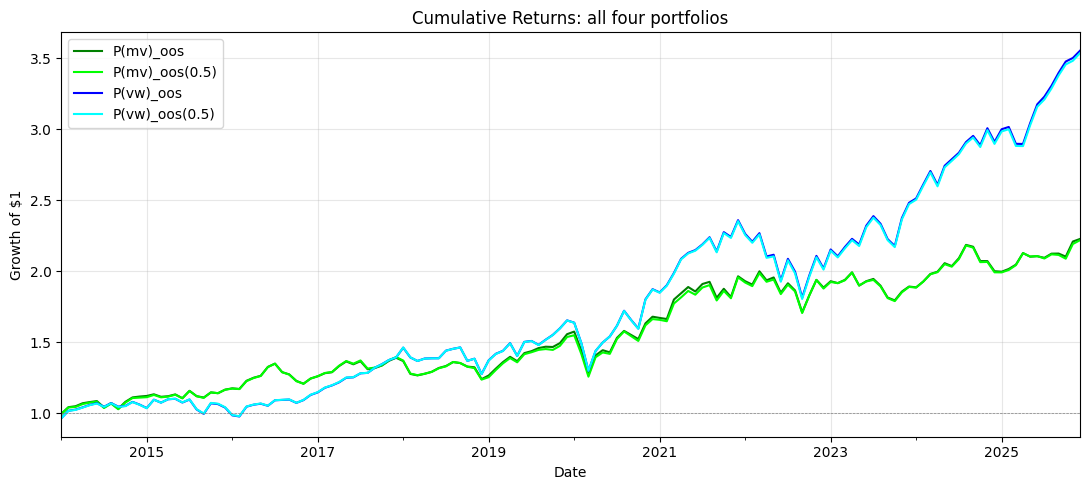

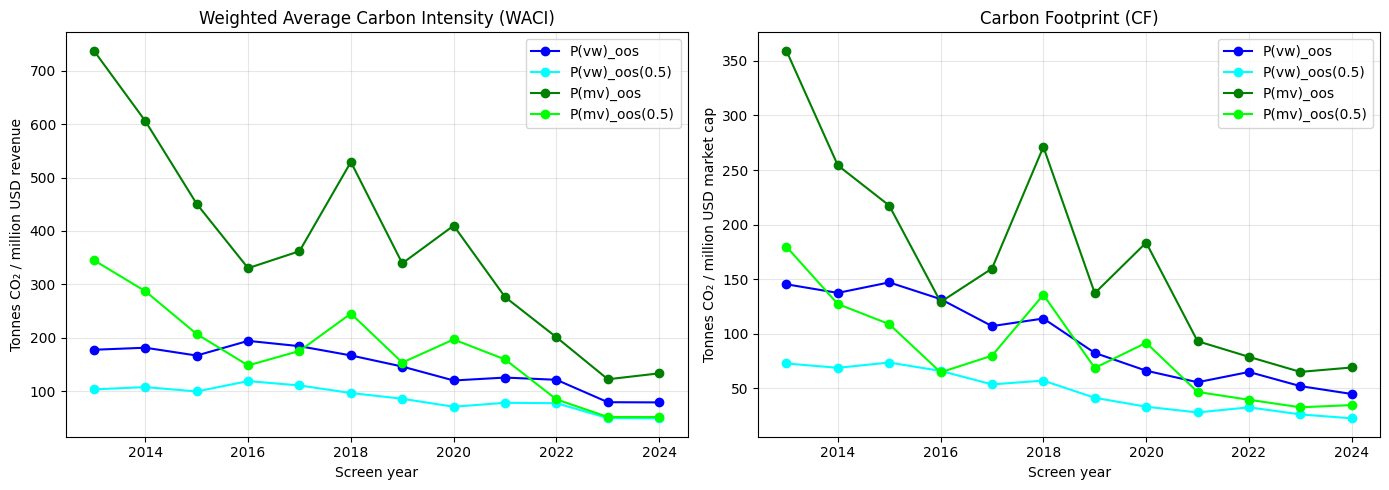

In [ ]:
# Align the four series on the same months
idx = (compare_df.index
       .intersection(mvp05_returns_idx.index)
       .intersection(te05_returns_idx.index))

mvp   = compare_df.loc[idx, "Rp_mvp"]
vw    = compare_df.loc[idx, "Rp_vw"]
mvp05 = mvp05_returns_idx.loc[idx]
te05  = te05_returns_idx.loc[idx]

# Performance stats
stats = pd.DataFrame([
    summary_stats(mvp,   "P(mv)_oos",      rf_monthly=rf_monthly_avg),
    summary_stats(mvp05, "P(mv)_oos(0.5)", rf_monthly=rf_monthly_avg),
    summary_stats(vw,    "P(vw)_oos",      rf_monthly=rf_monthly_avg),
    summary_stats(te05,  "P(vw)_oos(0.5)", rf_monthly=rf_monthly_avg),
]).set_index("portfolio")

# Average WACI and CF across screen years
years = sorted(set(mvp_waci_by_year) & set(mvp05_waci_by_year)
               & set(vw_waci_by_year) & set(te05_waci_by_year))
mean = lambda d: np.nanmean([d[y] for y in years])

table = pd.DataFrame({
    "P(mv)_oos":      [stats.loc["P(mv)_oos","ann_mean_return"],
                       stats.loc["P(mv)_oos","ann_volatility"],
                       stats.loc["P(mv)_oos","sharpe_ratio"],
                       stats.loc["P(mv)_oos","min_monthly_return"],
                       stats.loc["P(mv)_oos","max_monthly_return"],
                       mean(mvp_waci_by_year), mean(mvp_cf_by_year)],
    "P(mv)_oos(0.5)": [stats.loc["P(mv)_oos(0.5)","ann_mean_return"],
                       stats.loc["P(mv)_oos(0.5)","ann_volatility"],
                       stats.loc["P(mv)_oos(0.5)","sharpe_ratio"],
                       stats.loc["P(mv)_oos(0.5)","min_monthly_return"],
                       stats.loc["P(mv)_oos(0.5)","max_monthly_return"],
                       mean(mvp05_waci_by_year), mean(mvp05_cf_by_year)],
    "P(vw)_oos":      [stats.loc["P(vw)_oos","ann_mean_return"],
                       stats.loc["P(vw)_oos","ann_volatility"],
                       stats.loc["P(vw)_oos","sharpe_ratio"],
                       stats.loc["P(vw)_oos","min_monthly_return"],
                       stats.loc["P(vw)_oos","max_monthly_return"],
                       mean(vw_waci_by_year), mean(vw_cf_by_year)],
    "P(vw)_oos(0.5)": [stats.loc["P(vw)_oos(0.5)","ann_mean_return"],
                       stats.loc["P(vw)_oos(0.5)","ann_volatility"],
                       stats.loc["P(vw)_oos(0.5)","sharpe_ratio"],
                       stats.loc["P(vw)_oos(0.5)","min_monthly_return"],
                       stats.loc["P(vw)_oos(0.5)","max_monthly_return"],
                       mean(te05_waci_by_year), mean(te05_cf_by_year)],
}, index=["Ann. return", "Ann. volatility", "Sharpe ratio",
         "Min monthly", "Max monthly", "Avg WACI", "Avg CF"])

print(table.round(4).to_string())
table.to_csv(OUT_DIR / "section34_comparison_table.csv")

# Cumulative returns plot
fig, ax = plt.subplots(figsize=(11, 5))
(1+mvp).cumprod().plot(ax=ax, color="green",      label="P(mv)_oos")
(1+mvp05).cumprod().plot(ax=ax, color="#00ff00",label="P(mv)_oos(0.5)")
(1+vw).cumprod().plot(ax=ax, color="blue",        label="P(vw)_oos")
(1+te05).cumprod().plot(ax=ax, color="#00ffff", label="P(vw)_oos(0.5)")
ax.axhline(1, color="grey", linestyle="--", linewidth=0.5)
ax.set_title("Cumulative Returns: all four portfolios")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "section34_cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()

# WACI and CF comparison plot like before but with all four series
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(carbon_te["Year"], carbon_te["VW_WACI"],   marker="o", label="P(vw)_oos",      color="blue")
ax1.plot(carbon_te["Year"], carbon_te["TE05_WACI"], marker="o", label="P(vw)_oos(0.5)", color="#00ffff")
ax1.plot(carbon_compare["Year"], carbon_compare["MVP_WACI"],   marker="o", label="P(mv)_oos",      color="green")
ax1.plot(carbon_compare["Year"], carbon_compare["MVP05_WACI"], marker="o", label="P(mv)_oos(0.5)", color="#00ff00")
ax1.set_title("Weighted Average Carbon Intensity (WACI)")
ax1.set_ylabel("Tonnes CO₂ / million USD revenue")
ax1.set_xlabel("Screen year")
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(carbon_te["Year"], carbon_te["VW_CF"],   marker="o", label="P(vw)_oos",      color="blue")
ax2.plot(carbon_te["Year"], carbon_te["TE05_CF"], marker="o", label="P(vw)_oos(0.5)", color="#00ffff")
ax2.plot(carbon_compare["Year"], carbon_compare["MVP_CF"],   marker="o", label="P(mv)_oos",      color="green")
ax2.plot(carbon_compare["Year"], carbon_compare["MVP05_CF"], marker="o", label="P(mv)_oos(0.5)", color="#00ff00")
ax2.set_title("Carbon Footprint (CF)")
ax2.set_ylabel("Tonnes CO₂ / million USD market cap")
ax2.set_xlabel("Screen year")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "section34_carbon_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.1 Net Zero Portfolio — P(vw)\_oos(NZ)

We construct a **Net Zero** portfolio that stays as close as possible to the
value-weighted benchmark while reducing its carbon footprint by 10 % per year,
compounding from the 2013 VW baseline:

$$
\min_{\alpha_Y} \; TE(p,Y)^2 = (\alpha_Y - \alpha^{(vw)}_Y)^\top
\hat{\Sigma}_Y (\alpha_Y - \alpha^{(vw)}_Y)
$$

$$
\text{s.t.} \quad CF^{(p)}_Y \le (1-\theta)^{Y-Y_0+1} \cdot CF^{(vw)}_{Y_0},
\quad \alpha_Y^\top e = 1, \quad \alpha_{i,Y} \ge 0
$$

with $\theta = 10\%$, $Y_0 = 2013$ (first screen year), and
$CF^{(vw)}_{Y_0}$ the realised carbon footprint of the VW portfolio at end-2013.
The resulting portfolio is denoted **P(vw)\_oos(NZ)**.


  2013: limit = 130.709728  CF = 106.238506  TE = 0.000080
  2014: limit = 117.638755  CF = 104.639163  TE = 0.000067
  2015: limit = 105.874880  CF = 105.871956  TE = 0.000075
  2016: limit = 95.287392  CF = 95.283791  TE = 0.000073
  2017: limit = 85.758652  CF = 85.755688  TE = 0.000055
  2018: limit = 77.182787  CF = 77.178992  TE = 0.000095
  2019: limit = 69.464508  CF = 69.461690  TE = 0.000027
  2020: limit = 62.518058  CF = 62.503068  TE = 0.000034
  2021: limit = 56.266252  CF = 56.002383  TE = 0.000020
  2022: limit = 50.639627  CF = 50.638625  TE = 0.000041
  2023: limit = 45.575664  CF = 45.574543  TE = 0.000021
  2024: limit = 41.018098  CF = 41.018070  TE = 0.000008

P(vw)_oos(NZ) solved for 12 years, 144 monthly observations.


,Portfolio,Ann. return,Ann. volatility,Sharpe,Min monthly,Max monthly
0,P(vw)_oos,0.1161,0.1417,0.6958,-0.1307,0.1284
1,P(vw)_oos(NZ),0.1162,0.1417,0.6967,-0.1308,0.1283


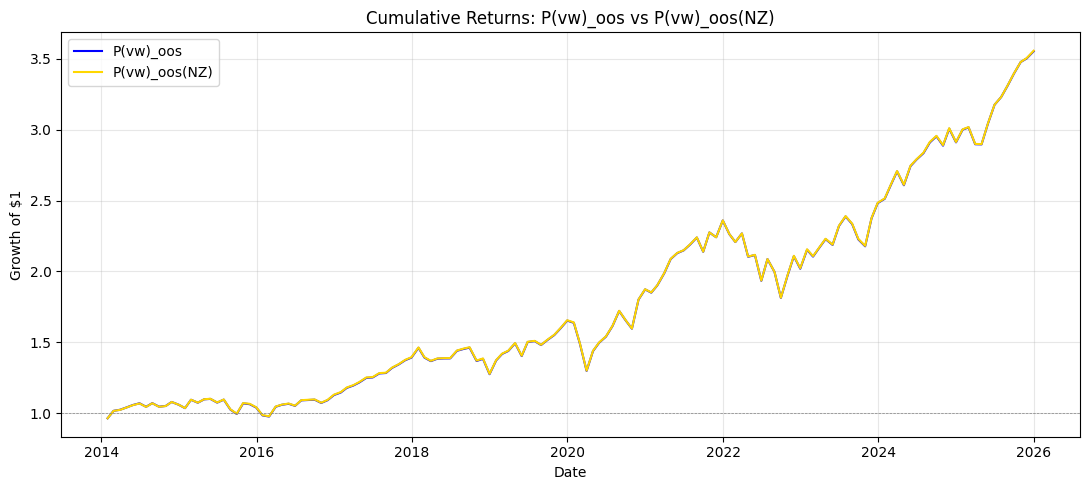

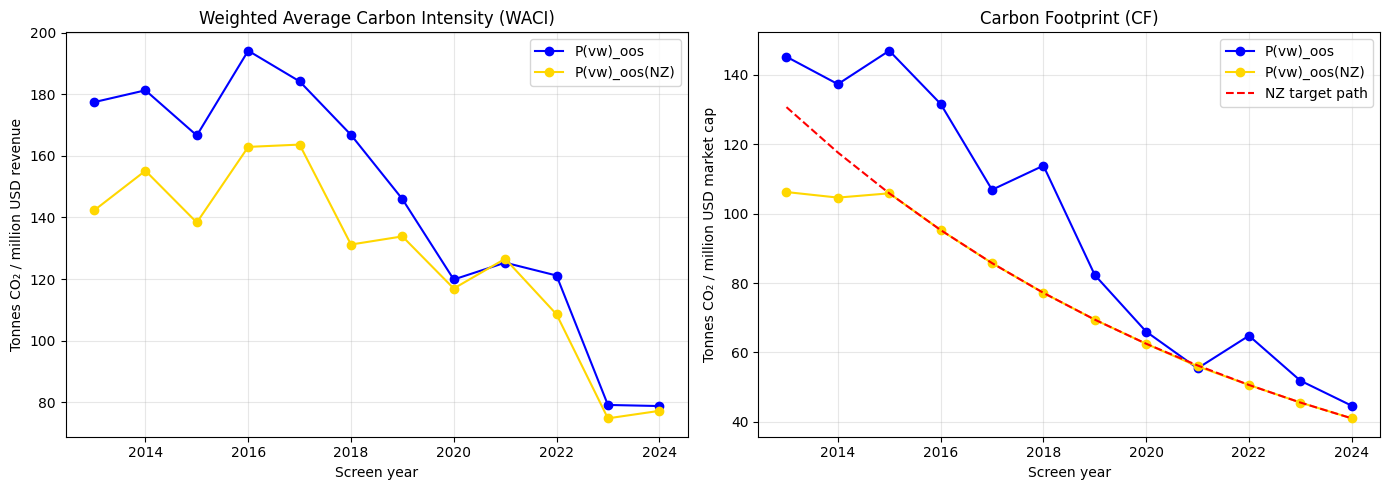


Final $1  →  P(vw)_oos: $3.553   P(vw)_oos(NZ): $3.556


In [ ]:
# =============================================================================
# 4.1 — P(vw)_oos(NZ): tracking-error min with rolling 10 %/yr carbon cut
# =============================================================================

THETA      = 0.10   # annual decarbonisation rate
Y0         = 2013   # base year (first screen year)
cf_vw_2013 = vw_cf_by_year[Y0]   # anchor: VW carbon footprint at end-2013

nz_weights_rows = []
nz_return_rows  = []
nz_summary_rows = []


for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1
    year_str        = str(year)

    # Target tightens each year: CF(p)_Y <= (1-theta)^(Y-Y0+1) * CF_vw_2013
    cf_limit = (1 - THETA) ** (year - Y0 + 1) * cf_vw_2013

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"],
        "ISIN",
    ].tolist()
    if not investable_isins:
        continue

    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year, window_years=WINDOW_YEARS)
    if not window_cols:
        continue

    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)
    if not valid_isins:
        continue

    year_end_col = get_december_col(mv_month_cols, year)
    if year_end_col is None:
        continue

    # VW benchmark weights on valid_isins
    cap_series = (
        mv_by_isin.reindex(valid_isins)[year_end_col]
        .apply(pd.to_numeric, errors="coerce").fillna(0.0).clip(lower=0.0)
    )
    total_cap = cap_series.sum()
    if total_cap <= 0:
        continue
    w_vw_arr = (cap_series / total_cap).values

    # Carbon coefficient vector: cf_coef[k] = E_{i,Y} / Cap_{i,Y}
    cf_coef   = np.zeros(len(valid_isins))
    n_missing = 0
    for k, isin in enumerate(valid_isins):
        co2_val = (
            co2_clean.loc[isin, year_str]
            if (isin in co2_clean.index and year_str in co2_clean.columns)
            else np.nan
        )
        cap_val = mv_by_isin.loc[isin, year_end_col] if isin in mv_by_isin.index else np.nan
        try:
            cap_val = float(cap_val)
        except Exception:
            cap_val = np.nan
        if pd.notna(co2_val) and pd.notna(cap_val) and cap_val > 0:
            cf_coef[k] = co2_val / cap_val
        else:
            n_missing += 1

    # Solve TE-min subject to the NZ carbon limit (reuse solver from 3.3)
    try:
        w_nz = solve_te_constrained(cov, w_vw_arr, cf_coef, cf_limit)
    except RuntimeError as e:
        print(f"  {year}: solver failed — {e}")
        continue

    realized_cf = float(cf_coef @ w_nz)
    realized_te = float(np.sqrt((w_nz - w_vw_arr) @ cov @ (w_nz - w_vw_arr)))
    print(
        f"  {year}: limit = {cf_limit:.6f}  "
        f"CF = {realized_cf:.6f}  TE = {realized_te:.6f}"
    )

    for isin, w in zip(valid_isins, w_nz):
        nz_weights_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "ISIN":            isin,
            "weight":          w,
        })

    nz_summary_rows.append({
        "screen_year":      year,
        "investment_year":  investment_year,
        "n_assets":         len(valid_isins),
        "n_missing_carbon": n_missing,
        "tracking_error":   realized_te,
        "realized_CF":      realized_cf,
        "cf_limit":         cf_limit,
    })

    # Out-of-sample monthly returns with weight drift
    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue
    current_weights = pd.Series(w_nz, index=valid_isins)

    for col in inv_cols:
        month_rets = (
            ri_ret_by_isin.reindex(valid_isins)[col]
            .apply(pd.to_numeric, errors="coerce")
        )
        valid_mask = month_rets.notna()
        w_m = current_weights[valid_mask]
        r_m = month_rets[valid_mask]
        rp  = float((w_m / w_m.sum() * r_m).sum()) if w_m.sum() > 1e-8 else 0.0
        nz_return_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "date":            pd.Timestamp(col),
            "Rp_nz":           rp,
        })
        new_w = current_weights.copy()
        new_w[valid_mask] = current_weights[valid_mask] * (1.0 + month_rets[valid_mask])
        if new_w.sum() > 1e-8:
            current_weights = new_w / new_w.sum()

nz_weights_by_year = pd.DataFrame(nz_weights_rows)
nz_monthly_returns = pd.DataFrame(nz_return_rows).sort_values("date").reset_index(drop=True)
nz_year_summary    = pd.DataFrame(nz_summary_rows)

print(f"\nP(vw)_oos(NZ) solved for {len(nz_summary_rows)} years, "
      f"{len(nz_monthly_returns)} monthly observations.")

# =============================================================================
# WACI and CF for P(vw)_oos(NZ)
# =============================================================================

nz_waci_by_year = {}
nz_cf_by_year   = {}

for year in range(START_YEAR, END_YEAR + 1):
    year_str     = str(year)
    year_weights = nz_weights_by_year[nz_weights_by_year["screen_year"] == year]
    if year_weights.empty:
        continue

    ci_year = carbon_intensity_by_year.get(year, {})

    # WACI = sum_i alpha_i * CI_i
    waci = sum(
        row["weight"] * ci_year.get(row["ISIN"], 0.0)
        for _, row in year_weights.iterrows()
    )
    nz_waci_by_year[year] = waci

    # CF = sum_i (alpha_i / Cap_i) * E_i
    year_end_col = get_december_col(mv_month_cols, year)
    cf_val = 0.0
    for _, row in year_weights.iterrows():
        isin = row["ISIN"]
        co2 = (
            co2_clean.loc[isin, year_str]
            if (isin in co2_clean.index and year_str in co2_clean.columns)
            else np.nan
        )
        cap = (
            mv_by_isin.loc[isin, year_end_col]
            if (year_end_col and isin in mv_by_isin.index)
            else np.nan
        )
        try:
            cap = float(cap)
        except Exception:
            cap = np.nan
        if pd.notna(co2) and pd.notna(cap) and cap > 0:
            cf_val += row["weight"] / cap * co2
    nz_cf_by_year[year] = cf_val

# =============================================================================
# Performance statistics
# =============================================================================

nz_rets_s = (
    nz_monthly_returns[["date", "Rp_nz"]]
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .sort_values("date").set_index("date")["Rp_nz"]
)

idx_nz = compare_df.index.intersection(nz_rets_s.index)
vw_a   = compare_df.loc[idx_nz, "Rp_vw"]
nz_a   = nz_rets_s.loc[idx_nz]

stats_vw = summary_stats(vw_a, "P(vw)_oos",     rf_monthly=rf_monthly_avg)
stats_nz = summary_stats(nz_a, "P(vw)_oos(NZ)", rf_monthly=rf_monthly_avg)

perf_nz = pd.DataFrame([stats_vw, stats_nz])[
    ["portfolio", "ann_mean_return", "ann_volatility",
     "sharpe_ratio", "min_monthly_return", "max_monthly_return"]
]
perf_nz.columns = ["Portfolio", "Ann. return", "Ann. volatility",
                   "Sharpe", "Min monthly", "Max monthly"]

display(perf_nz.round(4))
perf_nz.to_csv(OUT_DIR / "vw_vs_nz_performance_summary.csv", index=False)

# =============================================================================
# Cumulative returns
# =============================================================================

cum_vw = (1 + vw_a).cumprod()
cum_nz = (1 + nz_a).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cum_vw.index, cum_vw.values, "b",      label="P(vw)_oos")
ax.plot(cum_nz.index, cum_nz.values, "gold", label="P(vw)_oos(NZ)")
ax.axhline(1, color="grey", linestyle="--", linewidth=0.5)
ax.set_title("Cumulative Returns: P(vw)_oos vs P(vw)_oos(NZ)")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "vw_vs_nz_cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# WACI & CF evolution with NZ target path
# =============================================================================

years_plot  = sorted(set(nz_waci_by_year) & set(vw_waci_by_year))
target_path = [(1 - THETA) ** (y - Y0 + 1) * cf_vw_2013 for y in years_plot]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(years_plot, [vw_waci_by_year[y] for y in years_plot], "b-o", label="P(vw)_oos")
ax.plot(years_plot, [nz_waci_by_year[y] for y in years_plot], marker="o", color="gold", label="P(vw)_oos(NZ)")
ax.set_title("Weighted Average Carbon Intensity (WACI)")
ax.set_xlabel("Screen year"); ax.set_ylabel("Tonnes CO₂ / million USD revenue")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(years_plot, [vw_cf_by_year[y]  for y in years_plot], "b-o", label="P(vw)_oos")
ax.plot(years_plot, [nz_cf_by_year[y]  for y in years_plot], marker="o", color="gold", label="P(vw)_oos(NZ)")
ax.plot(years_plot, target_path,                              "r--", label="NZ target path")
ax.set_title("Carbon Footprint (CF)")
ax.set_xlabel("Screen year"); ax.set_ylabel("Tonnes CO₂ / million USD market cap")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "vw_vs_nz_carbon_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFinal $1  \u2192  P(vw)_oos: ${cum_vw.iloc[-1]:.3f}   "
      f"P(vw)_oos(NZ): ${cum_nz.iloc[-1]:.3f}")

## 4.2 Comparison of Value-Weighted Portfolios

We compare the three value-weighted-based portfolios over the full out-of-sample
period (Jan 2014 – Dec 2025):

| Portfolio | Strategy |
|---|---|
| P(vw)\_oos | Passive VW benchmark — no decarbonisation |
| P(vw)\_oos(0.5) | One-time 50 % CF reduction (Section 3.3) |
| P(vw)\_oos(NZ) | Net Zero: 10 %/yr cumulative CF reduction (Section 4.1) |

We report annualised performance statistics, a cumulative return chart for all
three portfolios, and the evolution of carbon footprints, including the NZ target path.


,Portfolio,Ann. return,Ann. volatility,Sharpe,Min monthly,Max monthly
0,P(vw)_oos,0.1161,0.1417,0.6958,-0.1307,0.1284
1,P(vw)_oos(0.5),0.1157,0.1417,0.6931,-0.1305,0.1288
2,P(vw)_oos(NZ),0.1162,0.1417,0.6967,-0.1308,0.1283


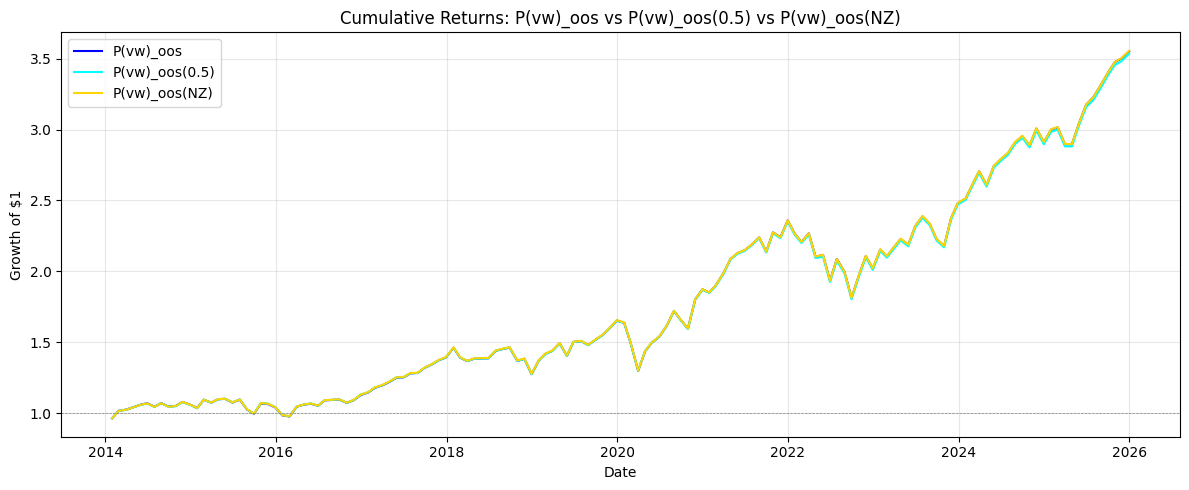


Final $1  →  P(vw)_oos: $3.553   P(vw)_oos(0.5): $3.535   P(vw)_oos(NZ): $3.556


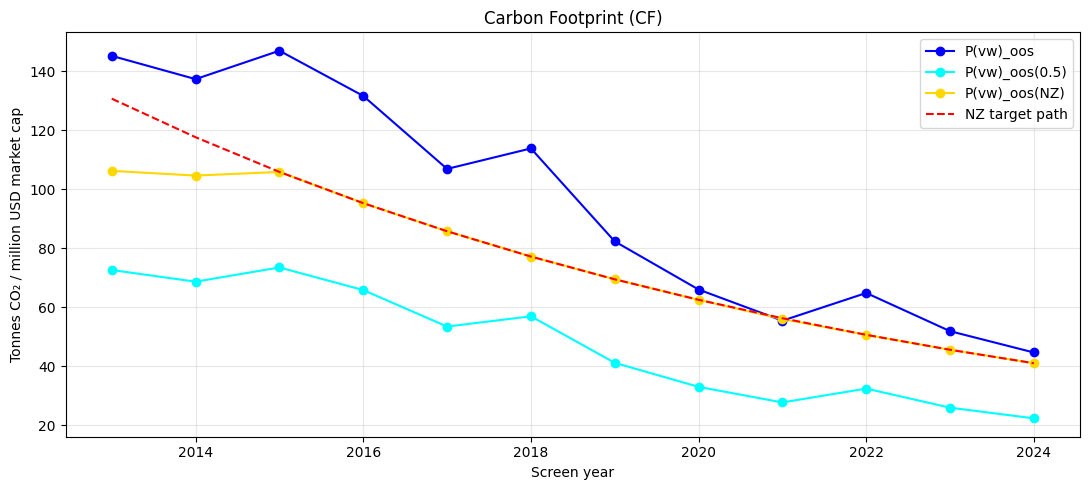

In [ ]:
# =============================================================================
# 4.2 — Three-way comparison: P(vw)_oos, P(vw)_oos(0.5), P(vw)_oos(NZ)
# =============================================================================

# --- A. Align return series to a common date index ---

te05_rets_s = (
    te05_monthly_returns[["date", "Rp_te05"]]
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .sort_values("date").set_index("date")["Rp_te05"]
)

idx_all = (
    compare_df.index
    .intersection(nz_rets_s.index)
    .intersection(te05_rets_s.index)
)

vw_r   = compare_df.loc[idx_all, "Rp_vw"]
te05_r = te05_rets_s.loc[idx_all]
nz_r   = nz_rets_s.loc[idx_all]

# --- B. Summary statistics table ---

stats_all = pd.DataFrame([
    summary_stats(vw_r,   "P(vw)_oos",      rf_monthly=rf_monthly_avg),
    summary_stats(te05_r, "P(vw)_oos(0.5)", rf_monthly=rf_monthly_avg),
    summary_stats(nz_r,   "P(vw)_oos(NZ)",  rf_monthly=rf_monthly_avg),
])[["portfolio", "ann_mean_return", "ann_volatility",
    "sharpe_ratio", "min_monthly_return", "max_monthly_return"]]
stats_all.columns = ["Portfolio", "Ann. return", "Ann. volatility",
                     "Sharpe", "Min monthly", "Max monthly"]

display(stats_all.round(4))
stats_all.to_csv(OUT_DIR / "section4_comparison_table.csv", index=False)

# --- C. Cumulative returns (all three) ---

cum_vw4  = (1 + vw_r).cumprod()
cum_te05 = (1 + te05_r).cumprod()
cum_nz4  = (1 + nz_r).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_vw4.index,  cum_vw4.values,  "b",      label="P(vw)_oos")
ax.plot(cum_te05.index, cum_te05.values, color="#00ffff", label="P(vw)_oos(0.5)")
ax.plot(cum_nz4.index,  cum_nz4.values,  "gold", label="P(vw)_oos(NZ)")
ax.axhline(1, color="grey", linestyle="--", linewidth=0.5)
ax.set_title("Cumulative Returns: P(vw)_oos vs P(vw)_oos(0.5) vs P(vw)_oos(NZ)")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "section4_cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFinal $1  \u2192  "
      f"P(vw)_oos: ${cum_vw4.iloc[-1]:.3f}   "
      f"P(vw)_oos(0.5): ${cum_te05.iloc[-1]:.3f}   "
      f"P(vw)_oos(NZ): ${cum_nz4.iloc[-1]:.3f}")

# --- D. Carbon Footprint evolution (all three + NZ target) plus WACI graph ---

years_cf  = sorted(set(vw_cf_by_year) & set(te05_cf_by_year) & set(nz_cf_by_year))
target_cf = [(1 - THETA) ** (y - Y0 + 1) * cf_vw_2013 for y in years_cf]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years_cf, [vw_cf_by_year[y]   for y in years_cf], "b-o",  label="P(vw)_oos")
ax.plot(years_cf, [te05_cf_by_year[y] for y in years_cf], marker="o", color="#00ffff",  label="P(vw)_oos(0.5)")
ax.plot(years_cf, [nz_cf_by_year[y]   for y in years_cf], marker="o", color="gold", label="P(vw)_oos(NZ)")
ax.plot(years_cf, target_cf,                               "r--",  label="NZ target path")
ax.set_title("Carbon Footprint (CF)")
ax.set_xlabel("Screen year"); ax.set_ylabel("Tonnes CO₂ / million USD market cap")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "section4_carbon_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Compare realized CFs and limits
import pandas as pd
diag = pd.DataFrame({
    "year": sorted(set(te05_year_summary.screen_year) & set(nz_year_summary.screen_year)),
})
diag["cf_05_limit"]  = diag.year.map(dict(zip(te05_year_summary.screen_year, te05_year_summary.cf_limit)))
diag["cf_05_realized"] = diag.year.map(dict(zip(te05_year_summary.screen_year, te05_year_summary.realized_CF)))
diag["cf_nz_limit"]  = diag.year.map(dict(zip(nz_year_summary.screen_year,  nz_year_summary.cf_limit)))
diag["cf_nz_realized"] = diag.year.map(dict(zip(nz_year_summary.screen_year, nz_year_summary.realized_CF)))
diag["nz_tighter_than_05"] = diag.cf_nz_limit < diag.cf_05_limit
print(diag.round(8))

# Are the weights actually identical?
merged = te05_weights_by_year.merge(
    nz_weights_by_year,
    on=["screen_year","ISIN"],
    suffixes=("_05","_nz"),
)
merged["diff"] = (merged.weight_05 - merged.weight_nz).abs()
print("Max weight difference between 0.5 and NZ:", merged["diff"].max())
print("Years where weights differ:", merged.loc[merged["diff"]>1e-6, "screen_year"].unique())

    year  cf_05_limit  cf_05_realized  cf_nz_limit  cf_nz_realized  \
0   2013    72.616515       72.615970   130.709728      106.238506   
1   2014    68.669999       68.659851   117.638755      104.639163   
2   2015    73.486941       73.486520   105.874880      105.871956   
3   2016    65.822777       65.821577    95.287392       95.283791   
4   2017    53.447802       53.447332    85.758652       85.755688   
5   2018    56.921456       56.921199    77.182787       77.178992   
6   2019    41.158768       41.158768    69.464508       69.461690   
7   2020    33.001280       33.000327    62.518058       62.503068   
8   2021    27.716431       27.716431    56.266252       56.002383   
9   2022    32.418401       32.418401    50.639627       50.638625   
10  2023    25.939890       25.939889    45.575664       45.574543   
11  2024    22.326022       22.326022    41.018098       41.018070   

    nz_tighter_than_05  
0                False  
1                False  
2             